<a href="https://colab.research.google.com/github/MDuke235/Assignment-1/blob/main/Copy_of_pv_multi_model_blocked_seasonal_kfold_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/data4dav/filtered1.csv")

Mounted at /content/drive


# PV fixed-horizon forecasting with blocked seasonal K-Fold cross-validation

Notebook này giữ nguyên hướng xử lý dữ liệu, feature engineering 67 features, các nhóm mô hình single/ensemble/deep learning như file trước, nhưng thay phần chia dữ liệu bằng **blocked seasonal K-Fold cross-validation** giống sơ đồ K-Fold bạn yêu cầu.

Ý tưởng split mới:
- Dữ liệu một năm được chia thành các block thời gian liên tiếp, mặc định 6 block, mỗi block 2 tháng.
- Mỗi fold chọn 1 block làm test.
- Một block khác làm validation.
- Các block còn lại làm train.
- Mỗi fold train lại model từ đầu, không dùng model, trọng số, prediction hay kết quả của fold trước.
- Một block từng làm test ở fold này có thể trở thành train ở fold khác, đúng tinh thần K-Fold.

Lưu ý quan trọng:
- Đây là **blocked seasonal K-Fold for robustness evaluation**, không phải strict chronological future-deployment split.
- Vì train có thể chứa các tháng sau test block, thiết kế này dùng để so sánh mô hình và đánh giá độ ổn định theo mùa trên dataset ít dữ liệu.
- Các feature vẫn được xây dựng leakage-safe ở cấp dự báo: measured variables chỉ lấy tại issue time hoặc quá khứ, không dùng measured variables tại target time.


## 1. Imports and configuration

In [ ]:
import os
import math
import time
import json
import warnings
import inspect
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet, HuberRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42

OUTPUT_DIR = Path("/content/pv_multi_model_blocked_seasonal_kfold_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FREQ_MINUTES = 15
STEPS_PER_HOUR = 4

HORIZONS = {
    "1h_ahead": 4,
    "2h_ahead": 8,
    "3h_ahead": 12,
}

# Main setting for the paper. Add "hourly_issue" later if needed.
RUN_MODES = ["15min_issue"]
# RUN_MODES = ["15min_issue", "hourly_issue"]

# If measured data are available 15 minutes late in a real production system, set this to 1.
MEASUREMENT_LATENCY_STEPS = 0

# Blocked seasonal K-Fold settings.
# With one year of data: 12 months / 2 months = 6 folds.
CV_MONTHS_PER_BLOCK = 2
CV_N_FOLDS = 6

# Validation block is selected cyclically relative to the test block.
# validation_block_index = (test_block_index + CV_VALIDATION_OFFSET) % n_blocks
CV_VALIDATION_OFFSET = 1

# Purge rows after held-out validation/test blocks from the training/dev data
# when those rows could contain lag/rolling features derived from the held-out block.
CV_PURGE_AFTER_HELDOUT = True

# Evaluation focus: model selection uses validation RMSE. R2 is reported as the second main metric.
SELECTION_METRIC = "RMSE"

SAFE_MAPE_FLOOR_FRAC = 0.05

USE_OPTIONAL_XGBOOST = True
USE_OPTIONAL_LIGHTGBM = True

print("Config ready.")
print("Raw df shape:", df.shape)
display(df.head())


Config ready.
Raw df shape: (35040, 20)


,采样结束时刻,采样起始时刻,时间间隔,气温,方位角,云层不透明度,露点温度,DHI（太阳散射辐射指数）,DNI（太阳直接辐射指数）,GHI（太阳总水平辐射）,GTI（固定倾角辐射）,GTI（跟踪倾角辐射）,实际功率,大气可降水量,相对湿度,降雪深度,地面气压,高度10m风向,高度10m风速,天顶角
0,2019-01-01 00:15:00,2019-01-01 00:00:00,PT15M,-7.9,78,5.7,-20.9,0,0,0,0,0,0.0,4.1,34.6,0.2,843.8,182,1.7,140
1,2019-01-01 00:30:00,2019-01-01 00:15:00,PT15M,-8.0,74,29.1,-20.9,0,0,0,0,0,0.0,4.1,34.8,0.2,843.8,181,1.8,143
2,2019-01-01 00:45:00,2019-01-01 00:30:00,PT15M,-8.1,71,50.7,-20.9,0,0,0,0,0,0.0,4.1,35.1,0.2,843.7,181,1.8,146
3,2019-01-01 01:00:00,2019-01-01 00:45:00,PT15M,-8.2,67,45.0,-20.8,0,0,0,0,0,0.0,4.1,35.4,0.2,843.7,182,1.9,149
4,2019-01-01 01:15:00,2019-01-01 01:00:00,PT15M,-8.3,62,31.8,-20.8,0,0,0,0,0,0.0,4.1,35.8,0.2,843.6,182,1.9,151


## 2. Rename columns and causal preprocessing

Không dùng `bfill` và không nội suy hai chiều. Các biến đo được chỉ được forward-fill ngắn hạn. Target `actual_power` không được điền bằng tương lai.

In [ ]:
COLUMN_MAP = {
    "采样结束时刻": "time",
    "采样起始时刻": "start_time",
    "时间间隔": "interval",
    "气温": "temperature",
    "方位角": "azimuth",
    "云层不透明度": "cloud_opacity",
    "露点温度": "dew_point",
    "DHI（太阳散射辐射指数）": "dhi",
    "DNI（太阳直接辐射指数）": "dni",
    "GHI（太阳总水平辐射）": "ghi",
    "GTI（固定倾角辐射）": "gti_fixed",
    "GTI（跟踪倾角辐射）": "gti_tracking",
    "实际功率": "actual_power",
    "大气可降水量": "precipitable_water",
    "相对湿度": "relative_humidity",
    "降雪深度": "snow_depth",
    "地面气压": "surface_pressure",
    "高度10m风向": "wind_direction_10m",
    "高度10m风速": "wind_speed_10m",
    "天顶角": "zenith_angle",
}

NUMERIC_COLUMNS = [
    "temperature", "azimuth", "cloud_opacity", "dew_point",
    "dhi", "dni", "ghi", "gti_fixed", "gti_tracking",
    "actual_power", "precipitable_water", "relative_humidity",
    "snow_depth", "surface_pressure", "wind_direction_10m",
    "wind_speed_10m", "zenith_angle"
]

NONNEGATIVE_COLUMNS = [
    "cloud_opacity", "dhi", "dni", "ghi", "gti_fixed", "gti_tracking",
    "actual_power", "precipitable_water", "relative_humidity",
    "snow_depth", "surface_pressure", "wind_speed_10m", "zenith_angle"
]

raw_df = df.copy()
work = raw_df.rename(columns=COLUMN_MAP).copy()

if "time" not in work.columns:
    raise ValueError("Không tìm thấy cột thời gian sau khi rename. Kiểm tra COLUMN_MAP.")

work["time"] = pd.to_datetime(work["time"])
work = work.sort_values("time").drop_duplicates("time").set_index("time")

missing_cols = [c for c in NUMERIC_COLUMNS if c not in work.columns]
if missing_cols:
    raise ValueError(f"Thiếu các cột bắt buộc sau khi rename: {missing_cols}")

for c in NUMERIC_COLUMNS:
    work[c] = pd.to_numeric(work[c], errors="coerce")

print("Original shape:", raw_df.shape)
print("Time range before reindex:", work.index.min(), "->", work.index.max())
print("Missing before reindex:", int(work[NUMERIC_COLUMNS].isna().sum().sum()))

full_index = pd.date_range(work.index.min(), work.index.max(), freq=f"{FREQ_MINUTES}min")
work = work.reindex(full_index)
work.index.name = "time"

print("Shape after reindex:", work.shape)
print("Missing after reindex before fill:", int(work[NUMERIC_COLUMNS].isna().sum().sum()))

feature_like_cols = [c for c in NUMERIC_COLUMNS if c != "actual_power"]
work[feature_like_cols] = work[feature_like_cols].ffill(limit=4)

for c in NONNEGATIVE_COLUMNS:
    work[c] = work[c].clip(lower=0)

pv_df = work.copy()

print("Final processed shape:", pv_df.shape)
print("Final time range:", pv_df.index.min(), "->", pv_df.index.max())
print("Missing after causal fill:", int(pv_df[NUMERIC_COLUMNS].isna().sum().sum()))

display(pv_df.head())

Original shape: (35040, 20)
Time range before reindex: 2019-01-01 00:15:00 -> 2020-01-01 00:00:00
Missing before reindex: 0
Shape after reindex: (35040, 19)
Missing after reindex before fill: 0
Final processed shape: (35040, 19)
Final time range: 2019-01-01 00:15:00 -> 2020-01-01 00:00:00
Missing after causal fill: 0


,start_time,interval,temperature,azimuth,cloud_opacity,dew_point,dhi,dni,ghi,gti_fixed,gti_tracking,actual_power,precipitable_water,relative_humidity,snow_depth,surface_pressure,wind_direction_10m,wind_speed_10m,zenith_angle
time,,,,,,,,,,,,,,,,,,,
2019-01-01 00:15:00,2019-01-01 00:00:00,PT15M,-7.9,78,5.7,-20.9,0,0,0,0,0,0.0,4.1,34.6,0.2,843.8,182,1.7,140
2019-01-01 00:30:00,2019-01-01 00:15:00,PT15M,-8.0,74,29.1,-20.9,0,0,0,0,0,0.0,4.1,34.8,0.2,843.8,181,1.8,143
2019-01-01 00:45:00,2019-01-01 00:30:00,PT15M,-8.1,71,50.7,-20.9,0,0,0,0,0,0.0,4.1,35.1,0.2,843.7,181,1.8,146
2019-01-01 01:00:00,2019-01-01 00:45:00,PT15M,-8.2,67,45.0,-20.8,0,0,0,0,0,0.0,4.1,35.4,0.2,843.7,182,1.9,149
2019-01-01 01:15:00,2019-01-01 01:00:00,PT15M,-8.3,62,31.8,-20.8,0,0,0,0,0,0.0,4.1,35.8,0.2,843.6,182,1.9,151


## 3. Leakage-safe 67-feature engineering

Bộ feature được giữ cố định cho cả 1h, 2h và 3h để so sánh công bằng. Measured variables được lấy tại issue time hoặc quá khứ; target-time measured variables bị cấm.

In [ ]:
def add_cyclic(values, period):
    values = np.asarray(values)
    return (
        np.sin(2 * np.pi * values / period),
        np.cos(2 * np.pi * values / period),
    )


def add_registry(registry, name, kind, source_lag_steps=None):
    registry[name] = {
        "feature": name,
        "kind": kind,
        "source_lag_steps": source_lag_steps,
    }


# Các biến thời tiết đo được, chỉ được lấy tại issue time hoặc quá khứ.
# Không dùng weather observed tại target time.
EXTRA_WEATHER_SCALAR_COLUMNS = [
    "temperature",
    "precipitable_water",
    "relative_humidity",
    "snow_depth",
    "surface_pressure",
    "wind_speed_10m",
]

# Lag 96 = cùng thời điểm ngày hôm trước.
# Lag 192 = cùng thời điểm 2 ngày trước.
# Lag 672 = cùng thời điểm 7 ngày trước.
# Nếu sợ nhiều feature quá, có thể đổi thành [96, 672].
EXTRA_WEATHER_LAGS = [96, 192, 672]


FIXED_FEATURES = [
    "target_quarter",
    "target_quarter_sin",
    "target_quarter_cos",
    "target_doy_sin",
    "target_doy_cos",

    "target_zenith_angle",
    "target_zenith_sin",
    "target_zenith_cos",
    "target_azimuth_sin",
    "target_azimuth_cos",
    "target_is_daylight",

    "issue_actual_power",
    "issue_ghi",
    "issue_dni",
    "issue_dhi",
    "issue_gti_fixed",
    "issue_gti_tracking",
    "issue_cloud_opacity",

    # Weather tại issue time.
    # Đây vẫn là dữ liệu quá khứ so với target y(t+H), vì trong build_intraday_dataset()
    # các cột này sẽ được shift về issue time.
    "issue_temperature",
    "issue_precipitable_water",
    "issue_relative_humidity",
    "issue_snow_depth",
    "issue_surface_pressure",
    "issue_wind_speed_10m",

    # wind_direction_10m được encode dạng vòng tròn.
    "issue_wind_direction_10m_sin",
    "issue_wind_direction_10m_cos",

    "actual_power_lag_96",
    "actual_power_lag_192",
    "actual_power_lag_672",

    "gti_fixed_lag_96",
    "gti_fixed_lag_672",
    "gti_tracking_lag_96",
    "gti_tracking_lag_672",

    "issue_actual_power_roll_4_mean",
    "issue_gti_fixed_roll_4_mean",
    "issue_gti_tracking_roll_4_mean",
    "issue_cloud_opacity_roll_4_mean",
    "issue_cloud_opacity_roll_96_mean",

    "issue_power_ramp_15m",
    "issue_power_ramp_1h",

    "power_same_time_7d_mean",
    "power_same_time_7d_max",
    "power_same_time_7d_min",
]


# Thêm lag cho các biến thời tiết scalar.
for c in EXTRA_WEATHER_SCALAR_COLUMNS:
    for lag in EXTRA_WEATHER_LAGS:
        FIXED_FEATURES.append(f"issue_{c}_lag_{lag}")


# Thêm lag cho wind direction, vẫn encode sin/cos.
for lag in EXTRA_WEATHER_LAGS:
    FIXED_FEATURES.append(f"issue_wind_direction_10m_lag_{lag}_sin")
    FIXED_FEATURES.append(f"issue_wind_direction_10m_lag_{lag}_cos")


print("Fixed feature count:", len(FIXED_FEATURES))

Fixed feature count: 67


In [ ]:
def build_intraday_dataset(horizon_steps, run_mode="15min_issue", latency_steps=0):
    source_shift = horizon_steps + latency_steps

    data = pd.DataFrame(index=pv_df.index)
    registry = {}

    data["y"] = pv_df["actual_power"]
    data["issue_time"] = data.index - pd.to_timedelta(horizon_steps * FREQ_MINUTES, unit="m")

    idx = pv_df.index
    quarter = idx.hour * 4 + idx.minute // 15

    data["target_quarter"] = quarter
    add_registry(registry, "target_quarter", "deterministic", 0)

    data["target_quarter_sin"], data["target_quarter_cos"] = add_cyclic(quarter, 96)
    data["target_doy_sin"], data["target_doy_cos"] = add_cyclic(idx.dayofyear, 365.25)

    for c in ["target_quarter_sin", "target_quarter_cos", "target_doy_sin", "target_doy_cos"]:
        add_registry(registry, c, "deterministic", 0)

    data["target_zenith_angle"] = pv_df["zenith_angle"]
    data["target_zenith_sin"] = np.sin(np.deg2rad(pv_df["zenith_angle"]))
    data["target_zenith_cos"] = np.cos(np.deg2rad(pv_df["zenith_angle"]))
    data["target_azimuth_sin"] = np.sin(np.deg2rad(pv_df["azimuth"]))
    data["target_azimuth_cos"] = np.cos(np.deg2rad(pv_df["azimuth"]))
    data["target_is_daylight"] = (pv_df["zenith_angle"] < 90).astype(int)

    for c in [
        "target_zenith_angle",
        "target_zenith_sin",
        "target_zenith_cos",
        "target_azimuth_sin",
        "target_azimuth_cos",
        "target_is_daylight",
    ]:
        add_registry(registry, c, "deterministic", 0)

    # Các biến đo được tại issue time.
    # Vì data.index đang là target time, nên phải shift(source_shift)
    # để lấy đúng giá trị tại issue time.
    issue_columns = [
        "actual_power",
        "ghi",
        "dni",
        "dhi",
        "gti_fixed",
        "gti_tracking",
        "cloud_opacity",

        "temperature",
        "precipitable_water",
        "relative_humidity",
        "snow_depth",
        "surface_pressure",
        "wind_speed_10m",
    ]

    for c in issue_columns:
        name = f"issue_{c}"
        data[name] = pv_df[c].shift(source_shift)
        add_registry(registry, name, "observed", source_shift)

    # wind_direction_10m là biến góc, không nên dùng raw degree.
    shifted_wind_direction = pv_df["wind_direction_10m"].shift(source_shift)
    data["issue_wind_direction_10m_sin"] = np.sin(np.deg2rad(shifted_wind_direction))
    data["issue_wind_direction_10m_cos"] = np.cos(np.deg2rad(shifted_wind_direction))

    add_registry(registry, "issue_wind_direction_10m_sin", "observed", source_shift)
    add_registry(registry, "issue_wind_direction_10m_cos", "observed", source_shift)

    # Lag của actual_power.
    # Các lag này là cùng target-time ở ngày trước / 2 ngày trước / 7 ngày trước.
    # Chúng vẫn an toàn vì lag 96/192/672 đều lớn hơn horizon 1h/2h/3h.
    for lag in [96, 192, 672]:
        data[f"actual_power_lag_{lag}"] = pv_df["actual_power"].shift(lag)
        add_registry(registry, f"actual_power_lag_{lag}", "observed", lag)

    # Lag của GTI.
    for c in ["gti_fixed", "gti_tracking"]:
        for lag in [96, 672]:
            name = f"{c}_lag_{lag}"
            data[name] = pv_df[c].shift(lag)
            add_registry(registry, name, "observed", lag)

    # Lag của các biến weather mới.
    # Ở đây dùng source_shift + lag, tức là lag được tính từ issue time,
    # không phải từ target time. Cách này chặt hơn và dễ bảo vệ leakage hơn.
    for c in EXTRA_WEATHER_SCALAR_COLUMNS:
        for lag in EXTRA_WEATHER_LAGS:
            name = f"issue_{c}_lag_{lag}"
            data[name] = pv_df[c].shift(source_shift + lag)
            add_registry(registry, name, "observed", source_shift + lag)

    # Lag của wind_direction_10m, encode sin/cos.
    for lag in EXTRA_WEATHER_LAGS:
        shifted_wind_lag = pv_df["wind_direction_10m"].shift(source_shift + lag)

        sin_name = f"issue_wind_direction_10m_lag_{lag}_sin"
        cos_name = f"issue_wind_direction_10m_lag_{lag}_cos"

        data[sin_name] = np.sin(np.deg2rad(shifted_wind_lag))
        data[cos_name] = np.cos(np.deg2rad(shifted_wind_lag))

        add_registry(registry, sin_name, "observed", source_shift + lag)
        add_registry(registry, cos_name, "observed", source_shift + lag)

    shifted_power = pv_df["actual_power"].shift(source_shift)
    shifted_gti_fixed = pv_df["gti_fixed"].shift(source_shift)
    shifted_gti_tracking = pv_df["gti_tracking"].shift(source_shift)
    shifted_cloud = pv_df["cloud_opacity"].shift(source_shift)

    data["issue_actual_power_roll_4_mean"] = shifted_power.rolling(4, min_periods=2).mean()
    data["issue_gti_fixed_roll_4_mean"] = shifted_gti_fixed.rolling(4, min_periods=2).mean()
    data["issue_gti_tracking_roll_4_mean"] = shifted_gti_tracking.rolling(4, min_periods=2).mean()
    data["issue_cloud_opacity_roll_4_mean"] = shifted_cloud.rolling(4, min_periods=2).mean()
    data["issue_cloud_opacity_roll_96_mean"] = shifted_cloud.rolling(96, min_periods=24).mean()

    for c in [
        "issue_actual_power_roll_4_mean",
        "issue_gti_fixed_roll_4_mean",
        "issue_gti_tracking_roll_4_mean",
        "issue_cloud_opacity_roll_4_mean",
        "issue_cloud_opacity_roll_96_mean",
    ]:
        add_registry(registry, c, "observed", source_shift)

    data["issue_power_ramp_15m"] = (
        pv_df["actual_power"].shift(source_shift)
        - pv_df["actual_power"].shift(source_shift + 1)
    )

    data["issue_power_ramp_1h"] = (
        pv_df["actual_power"].shift(source_shift)
        - pv_df["actual_power"].shift(source_shift + 4)
    )

    for c in ["issue_power_ramp_15m", "issue_power_ramp_1h"]:
        add_registry(registry, c, "observed", source_shift)

    same_power_df = pd.concat(
        [pv_df["actual_power"].shift(96 * k) for k in range(1, 8)],
        axis=1,
    )

    data["power_same_time_7d_mean"] = same_power_df.mean(axis=1)
    data["power_same_time_7d_max"] = same_power_df.max(axis=1)
    data["power_same_time_7d_min"] = same_power_df.min(axis=1)

    for c in ["power_same_time_7d_mean", "power_same_time_7d_max", "power_same_time_7d_min"]:
        add_registry(registry, c, "observed", 96)

    if run_mode == "hourly_issue":
        data = data[data.index.minute == 0].copy()

    keep_cols = ["y", "issue_time"] + FIXED_FEATURES

    missing_features = [c for c in keep_cols if c not in data.columns]
    if missing_features:
        raise ValueError(f"Missing generated features: {missing_features}")

    data = data[keep_cols].dropna().sort_index().copy()
    registry_df = pd.DataFrame(registry.values())

    required_lag = source_shift
    unsafe = registry_df[
        (registry_df["kind"] == "observed")
        & (registry_df["source_lag_steps"] < required_lag)
    ]

    if len(unsafe) > 0:
        raise ValueError(f"Unsafe features detected for horizon={horizon_steps}:\n{unsafe}")

    return data, FIXED_FEATURES.copy(), registry_df


for mode in RUN_MODES:
    print("\nRUN MODE:", mode)
    for task, H in HORIZONS.items():
        tmp_data, tmp_features, tmp_registry = build_intraday_dataset(
            H,
            run_mode=mode,
            latency_steps=MEASUREMENT_LATENCY_STEPS,
        )
        print(
            task,
            "| rows:", len(tmp_data),
            "| features:", len(tmp_features),
            "| range:", tmp_data.index.min(), "->", tmp_data.index.max(),
        )


RUN MODE: 15min_issue
1h_ahead | rows: 34364 | features: 67 | range: 2019-01-08 01:15:00 -> 2020-01-01 00:00:00
2h_ahead | rows: 34360 | features: 67 | range: 2019-01-08 02:15:00 -> 2020-01-01 00:00:00
3h_ahead | rows: 34356 | features: 67 | range: 2019-01-08 03:15:00 -> 2020-01-01 00:00:00


## 4. Feature availability audit

Cell này kiểm tra feature availability. Nếu một observed feature có source lag nhỏ hơn horizon yêu cầu, notebook sẽ dừng vì có rủi ro leakage.

In [ ]:
for mode in RUN_MODES:
    for task, H in HORIZONS.items():
        data, feature_cols, registry_df = build_intraday_dataset(
            H, run_mode=mode, latency_steps=MEASUREMENT_LATENCY_STEPS
        )
        required_lag = H + MEASUREMENT_LATENCY_STEPS
        observed = registry_df[registry_df["kind"] == "observed"].copy()
        unsafe = observed[observed["source_lag_steps"] < required_lag]

        print("\n" + "=" * 90)
        print(mode, task, "required_lag =", required_lag)
        print("Feature count:", len(feature_cols))
        print("Observed feature count:", len(observed))
        print("Unsafe feature count:", len(unsafe))

        if len(feature_cols) != 67:
            raise ValueError(f"Expected 67 features, got {len(feature_cols)}")

        if len(unsafe) > 0:
            display(unsafe)
            raise ValueError("Leakage risk found in observed features.")

print("All feature availability checks passed. Fixed feature count = 67.")


15min_issue 1h_ahead required_lag = 4
Feature count: 67
Observed feature count: 56
Unsafe feature count: 0

15min_issue 2h_ahead required_lag = 8
Feature count: 67
Observed feature count: 56
Unsafe feature count: 0

15min_issue 3h_ahead required_lag = 12
Feature count: 67
Observed feature count: 56
Unsafe feature count: 0
All feature availability checks passed. Fixed feature count = 67.


## 5. Metrics

Model selection trong notebook này dùng validation RMSE. R2 được báo cáo song song vì bài báo tập trung vào RMSE và explained variance. Daylight MAPE vẫn được giữ như metric phụ cho PV daytime behavior.

In [ ]:
def apply_night_rule(part, pred):
    pred = np.asarray(pred, dtype=float).copy()
    night_mask = part["target_zenith_angle"].to_numpy() >= 90
    pred[night_mask] = 0.0
    return pred


def postprocess_prediction(part, pred, capacity):
    pred = np.asarray(pred, dtype=float)
    pred = np.nan_to_num(pred, nan=0.0, posinf=capacity, neginf=0.0)
    pred = np.clip(pred, 0, capacity)
    pred = apply_night_rule(part, pred)
    return pred


def calc_metrics(part, pred, capacity):
    y_true = part["y"].to_numpy(dtype=float)
    y_pred = postprocess_prediction(part, pred, capacity)

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    out = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2_score(y_true, y_pred),
        "nRMSE_percent": rmse / capacity * 100,
        "nMAE_percent": mae / capacity * 100,
        "bias": float(np.mean(y_pred - y_true)),
    }

    daylight_mask = (
        (part["target_zenith_angle"].to_numpy() < 90)
        & (y_true > 0.01 * capacity)
    )

    out["daylight_points"] = int(daylight_mask.sum())

    if daylight_mask.sum() == 0:
        out.update({
            "daylight_RMSE": np.nan,
            "daylight_MAE": np.nan,
            "daylight_nRMSE_percent": np.nan,
            "daylight_MAPE_percent": np.nan,
            "daylight_safe_MAPE_percent": np.nan,
            "daylight_WMAPE_percent": np.nan,
            "daylight_sMAPE_percent": np.nan,
            "daylight_R2": np.nan,
            "daylight_bias": np.nan,
        })
        return out

    yd = y_true[daylight_mask]
    yp = y_pred[daylight_mask]
    abs_err = np.abs(yd - yp)

    daylight_rmse = math.sqrt(mean_squared_error(yd, yp))
    daylight_mae = mean_absolute_error(yd, yp)

    out.update({
        "daylight_RMSE": daylight_rmse,
        "daylight_MAE": daylight_mae,
        "daylight_nRMSE_percent": daylight_rmse / capacity * 100,
        "daylight_MAPE_percent": float(np.mean(abs_err / yd) * 100),
        "daylight_safe_MAPE_percent": float(np.mean(abs_err / np.maximum(yd, SAFE_MAPE_FLOOR_FRAC * capacity)) * 100),
        "daylight_WMAPE_percent": float(abs_err.sum() / max(yd.sum(), 1e-9) * 100),
        "daylight_sMAPE_percent": float(np.mean(2 * abs_err / (np.abs(yd) + np.abs(yp) + 1e-9)) * 100),
        "daylight_R2": r2_score(yd, yp),
        "daylight_bias": float(np.mean(yp - yd)),
    })

    return out


def selection_score(metrics):
    # Main paper focus: lower RMSE is better. R2 is reported together with RMSE.
    return metrics["RMSE"]


def make_training_weights(part, capacity):
    y = part["y"].to_numpy(dtype=float)
    daylight_mask = (
        (part["target_zenith_angle"].to_numpy() < 90)
        & (y > 0.01 * capacity)
    )
    weights = np.full(len(part), 0.20, dtype=float)
    weights[daylight_mask] = 1.0 / np.maximum(y[daylight_mask], SAFE_MAPE_FLOOR_FRAC * capacity)
    weights = weights / np.mean(weights)
    return weights

## 6. Blocked seasonal K-Fold split

Đây là cách chia giống K-Fold trong hình bạn gửi, nhưng dùng **contiguous calendar blocks** thay vì random samples:

- Chia năm thành các block thời gian liên tiếp, mặc định 2 tháng/block.
- Mỗi fold chọn một block làm test.
- Một block khác làm validation.
- Các block còn lại làm train.
- Mỗi fold train lại từ đầu; fold sau không dùng kết quả/model/prediction của fold trước.
- Một block từng làm test ở fold này có thể được dùng làm train ở fold khác.

Cell này cũng purge các dòng train/dev ngay sau held-out blocks nếu các dòng đó có thể dùng held-out observations qua lag/rolling features. Điều này giúp giảm rủi ro held-out block bị lọt ngược vào training qua feature history.


In [ ]:
def _contiguous_segments_from_index(index, freq_minutes=15):
    """Return contiguous time segments from a DatetimeIndex."""
    idx = pd.DatetimeIndex(index).sort_values().unique()
    if len(idx) == 0:
        return []

    gap = pd.Timedelta(minutes=freq_minutes * 1.5)
    segments = []
    start = idx[0]
    prev = idx[0]

    for current in idx[1:]:
        if current - prev > gap:
            segments.append((start, prev))
            start = current
        prev = current

    segments.append((start, prev))
    return segments


def _format_segments(segments):
    if not segments:
        return ""
    return "; ".join([f"{s:%Y-%m-%d}→{e:%Y-%m-%d}" for s, e in segments])


def _make_calendar_month_blocks(data, months_per_block=2, min_block_points=96):
    """Create contiguous calendar-month blocks, e.g. Jan-Feb, Mar-Apr, ..., Nov-Dec."""
    if not isinstance(data.index, pd.DatetimeIndex):
        raise TypeError("data.index must be a DatetimeIndex.")

    month_index = data.index.to_period("M")
    all_months = list(pd.period_range(month_index.min(), month_index.max(), freq="M"))

    blocks = []
    for block_id, start_pos in enumerate(range(0, len(all_months), months_per_block), start=1):
        block_months = all_months[start_pos:start_pos + months_per_block]
        if len(block_months) == 0:
            continue

        mask = month_index.isin(block_months)
        block_data = data.loc[mask]
        if len(block_data) < min_block_points:
            continue

        label = "+".join([m.strftime("%b") for m in block_months])
        blocks.append({
            "block_id": block_id,
            "months": block_months,
            "label": label,
            "mask": mask,
            "start": block_data.index.min(),
            "end": block_data.index.max(),
            "rows": len(block_data),
            "days": len(pd.unique(block_data.index.date)),
        })

    if len(blocks) < 3:
        raise ValueError("Need at least 3 calendar blocks for train/validation/test blocked K-Fold.")

    return blocks


def _remove_rows_after_blocks(mask, data, heldout_blocks, purge_after_steps):
    """
    Remove rows after held-out blocks if their lag/rolling features may depend on that block.

    For a target-time row after a held-out block, features such as lag_96, rolling_96,
    or lag_672 may use observations from the held-out period. These rows are removed
    from train/dev to prevent the held-out block from entering training through history features.
    """
    if purge_after_steps is None or purge_after_steps <= 0:
        return mask

    out = np.asarray(mask).copy()
    purge_delta = pd.Timedelta(minutes=int(purge_after_steps) * FREQ_MINUTES)

    for b in heldout_blocks:
        end = b["end"]
        purge_zone = (data.index > end) & (data.index <= end + purge_delta)
        out = out & (~purge_zone)

    return out


def make_blocked_seasonal_kfold_folds(
    data,
    horizon_steps,
    months_per_block=2,
    n_folds=None,
    validation_offset=1,
    purge_after_heldout_steps=None,
    min_block_points=96,
):
    """
    Blocked seasonal K-Fold with contiguous calendar blocks.

    Each fold:
    - one block is test;
    - one different block is validation;
    - remaining blocks are train;
    - the model is trained from scratch inside each fold;
    - test block can be used as train in other folds, exactly like K-Fold CV.

    This split is for seasonal robustness/model comparison on one-year data.
    It is not a strict future-only chronological deployment split.
    """
    data = data.sort_index().copy()
    blocks = _make_calendar_month_blocks(
        data,
        months_per_block=months_per_block,
        min_block_points=min_block_points,
    )

    n_blocks = len(blocks)
    if n_folds is None:
        n_folds = n_blocks
    n_folds = min(int(n_folds), n_blocks)

    if n_blocks < 3:
        raise ValueError("Need at least three blocks: train, validation, and test.")

    folds = []
    for fold_idx in range(n_folds):
        test_block_idx = fold_idx
        val_block_idx = (fold_idx + validation_offset) % n_blocks
        if val_block_idx == test_block_idx:
            val_block_idx = (test_block_idx + 1) % n_blocks

        test_block = blocks[test_block_idx]
        val_block = blocks[val_block_idx]
        train_blocks = [b for j, b in enumerate(blocks) if j not in [test_block_idx, val_block_idx]]

        test_mask = np.asarray(test_block["mask"]).copy()
        val_mask = np.asarray(val_block["mask"]).copy()
        train_mask = np.ones(len(data), dtype=bool)
        train_mask = train_mask & (~test_mask) & (~val_mask)

        if CV_PURGE_AFTER_HELDOUT:
            # For validation selection: train should not use validation/test observations through lag/rolling history.
            train_mask = _remove_rows_after_blocks(
                train_mask,
                data,
                [test_block, val_block],
                purge_after_heldout_steps,
            )

            # For final refit on dev=train+validation: validation must also not use test observations through history.
            val_mask = _remove_rows_after_blocks(
                val_mask,
                data,
                [test_block],
                purge_after_heldout_steps,
            )

        train = data.loc[train_mask].copy()
        val = data.loc[val_mask].copy()
        test = data.loc[test_mask].copy()

        # Hard disjointness checks inside each fold.
        # The same calendar block may be reused as train in another fold,
        # but within one fold train/validation/test target rows must be separate.
        if not train.index.intersection(val.index).empty:
            raise AssertionError("Train and validation overlap inside one fold.")
        if not train.index.intersection(test.index).empty:
            raise AssertionError("Train and test overlap inside one fold.")
        if not val.index.intersection(test.index).empty:
            raise AssertionError("Validation and test overlap inside one fold.")

        dev = pd.concat([train, val], axis=0).sort_index()

        if len(train) < min_block_points or len(val) < min_block_points or len(test) < min_block_points:
            print(
                f"Skipping fold {fold_idx + 1}: insufficient rows "
                f"train={len(train)}, val={len(val)}, test={len(test)}"
            )
            continue

        train_segments = _contiguous_segments_from_index(train.index, FREQ_MINUTES)
        val_segments = _contiguous_segments_from_index(val.index, FREQ_MINUTES)
        test_segments = _contiguous_segments_from_index(test.index, FREQ_MINUTES)

        folds.append({
            "fold_id": fold_idx + 1,
            "split_strategy": "blocked_seasonal_kfold",
            "horizon_steps": horizon_steps,
            "train": train,
            "val": val,
            "dev": dev,
            "test": test,
            "test_block_id": test_block["block_id"],
            "validation_block_id": val_block["block_id"],
            "test_block": test_block["label"],
            "validation_block": val_block["label"],
            "train_blocks": "+".join([b["label"] for b in train_blocks]),
            "train_start": train.index.min(),
            "train_end": train.index.max(),
            "val_start": val.index.min(),
            "val_end": val.index.max(),
            "test_start": test.index.min(),
            "test_end": test.index.max(),
            "train_segments": train_segments,
            "val_segments": val_segments,
            "test_segments": test_segments,
            "train_segments_text": _format_segments(train_segments),
            "val_segments_text": _format_segments(val_segments),
            "test_segments_text": _format_segments(test_segments),
            "train_rows": len(train),
            "val_rows": len(val),
            "test_rows": len(test),
            "train_days": len(pd.unique(train.index.date)),
            "val_days": len(pd.unique(val.index.date)),
            "test_days": len(pd.unique(test.index.date)),
            "purge_after_heldout_steps": purge_after_heldout_steps if CV_PURGE_AFTER_HELDOUT else 0,
        })

    return folds


def summarize_blocked_folds_for_task(data, horizon_steps, registry_df):
    max_source_lag_steps = int(registry_df["source_lag_steps"].fillna(0).max())
    purge_steps = max_source_lag_steps if CV_PURGE_AFTER_HELDOUT else 0

    folds = make_blocked_seasonal_kfold_folds(
        data,
        horizon_steps,
        months_per_block=CV_MONTHS_PER_BLOCK,
        n_folds=CV_N_FOLDS,
        validation_offset=CV_VALIDATION_OFFSET,
        purge_after_heldout_steps=purge_steps,
    )

    rows = []
    for f in folds:
        rows.append({k: f[k] for k in [
            "fold_id", "split_strategy", "test_block", "validation_block", "train_blocks",
            "train_start", "train_end", "val_start", "val_end", "test_start", "test_end",
            "train_segments", "val_segments", "test_segments",
            "train_segments_text", "val_segments_text", "test_segments_text",
            "train_rows", "val_rows", "test_rows", "train_days", "val_days", "test_days",
            "purge_after_heldout_steps"
        ]})
    return pd.DataFrame(rows), folds


all_fold_summaries = []

for mode in RUN_MODES:
    for task, H in HORIZONS.items():
        data, feature_cols, registry_df = build_intraday_dataset(H, run_mode=mode)
        fold_summary, folds = summarize_blocked_folds_for_task(data, H, registry_df)
        fold_summary["run_mode"] = mode
        fold_summary["task"] = task
        all_fold_summaries.append(fold_summary)
        print("\n" + "=" * 100)
        print(mode, task, "| folds:", len(folds))
        display(fold_summary[[
            "fold_id", "test_block", "validation_block", "train_blocks",
            "train_rows", "val_rows", "test_rows",
            "train_segments_text", "val_segments_text", "test_segments_text",
            "purge_after_heldout_steps",
        ]])

cv_fold_summary = pd.concat(all_fold_summaries, ignore_index=True)
cv_fold_summary.to_csv(OUTPUT_DIR / "cv_fold_summary.csv", index=False)
print("Saved:", OUTPUT_DIR / "cv_fold_summary.csv")



15min_issue 1h_ahead | folds: 6


,fold_id,test_block,validation_block,train_blocks,train_rows,val_rows,test_rows,train_segments_text,val_segments_text,test_segments_text,purge_after_heldout_steps
0,1,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,22845,5180,4987,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,676
1,2,Mar+Apr,May+Jun,Jan+Feb+Jul+Aug+Sep+Oct+Nov+Dec,21976,5180,5856,2019-01-08→2019-02-28; 2019-07-08→2020-01-01,2019-05-08→2019-06-30,2019-03-01→2019-04-30,676
2,3,May+Jun,Jul+Aug,Jan+Feb+Mar+Apr+Sep+Oct+Nov+Dec,21880,5276,5856,2019-01-08→2019-04-30; 2019-09-08→2020-01-01,2019-07-08→2019-08-31,2019-05-01→2019-06-30,676
3,4,Jul+Aug,Sep+Oct,Jan+Feb+Mar+Apr+May+Jun+Nov+Dec,21880,5180,5952,2019-01-08→2019-06-30; 2019-11-08→2020-01-01,2019-09-08→2019-10-31,2019-07-01→2019-08-31,676
4,5,Sep+Oct,Nov+Dec,Jan+Feb+Mar+Apr+May+Jun+Jul+Aug,22651,5180,5856,2019-01-08→2019-08-31,2019-11-08→2019-12-31,2019-09-01→2019-10-31,676
5,6,Nov+Dec,Jan+Feb,Mar+Apr+May+Jun+Jul+Aug+Sep+Oct,22844,4987,5856,2019-03-08→2019-10-31,2019-01-08→2019-02-28,2019-11-01→2019-12-31,676



15min_issue 2h_ahead | folds: 6


,fold_id,test_block,validation_block,train_blocks,train_rows,val_rows,test_rows,train_segments_text,val_segments_text,test_segments_text,purge_after_heldout_steps
0,1,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,22841,5176,4983,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,680
1,2,Mar+Apr,May+Jun,Jan+Feb+Jul+Aug+Sep+Oct+Nov+Dec,21968,5176,5856,2019-01-08→2019-02-28; 2019-07-08→2020-01-01,2019-05-08→2019-06-30,2019-03-01→2019-04-30,680
2,3,May+Jun,Jul+Aug,Jan+Feb+Mar+Apr+Sep+Oct+Nov+Dec,21872,5272,5856,2019-01-08→2019-04-30; 2019-09-08→2020-01-01,2019-07-08→2019-08-31,2019-05-01→2019-06-30,680
3,4,Jul+Aug,Sep+Oct,Jan+Feb+Mar+Apr+May+Jun+Nov+Dec,21872,5176,5952,2019-01-08→2019-06-30; 2019-11-08→2020-01-01,2019-09-08→2019-10-31,2019-07-01→2019-08-31,680
4,5,Sep+Oct,Nov+Dec,Jan+Feb+Mar+Apr+May+Jun+Jul+Aug,22647,5176,5856,2019-01-08→2019-08-31,2019-11-08→2019-12-31,2019-09-01→2019-10-31,680
5,6,Nov+Dec,Jan+Feb,Mar+Apr+May+Jun+Jul+Aug+Sep+Oct,22840,4983,5856,2019-03-08→2019-10-31,2019-01-08→2019-02-28,2019-11-01→2019-12-31,680



15min_issue 3h_ahead | folds: 6


,fold_id,test_block,validation_block,train_blocks,train_rows,val_rows,test_rows,train_segments_text,val_segments_text,test_segments_text,purge_after_heldout_steps
0,1,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,22837,5172,4979,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,684
1,2,Mar+Apr,May+Jun,Jan+Feb+Jul+Aug+Sep+Oct+Nov+Dec,21960,5172,5856,2019-01-08→2019-02-28; 2019-07-08→2020-01-01,2019-05-08→2019-06-30,2019-03-01→2019-04-30,684
2,3,May+Jun,Jul+Aug,Jan+Feb+Mar+Apr+Sep+Oct+Nov+Dec,21864,5268,5856,2019-01-08→2019-04-30; 2019-09-08→2020-01-01,2019-07-08→2019-08-31,2019-05-01→2019-06-30,684
3,4,Jul+Aug,Sep+Oct,Jan+Feb+Mar+Apr+May+Jun+Nov+Dec,21864,5172,5952,2019-01-08→2019-06-30; 2019-11-08→2020-01-01,2019-09-08→2019-10-31,2019-07-01→2019-08-31,684
4,5,Sep+Oct,Nov+Dec,Jan+Feb+Mar+Apr+May+Jun+Jul+Aug,22643,5172,5856,2019-01-08→2019-08-31,2019-11-08→2019-12-31,2019-09-01→2019-10-31,684
5,6,Nov+Dec,Jan+Feb,Mar+Apr+May+Jun+Jul+Aug+Sep+Oct,22836,4979,5856,2019-03-08→2019-10-31,2019-01-08→2019-02-28,2019-11-01→2019-12-31,684


Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/cv_fold_summary.csv


## 7. Models

In [ ]:
def baseline_predictions(part):
    return {
        "Persistence": part["issue_actual_power"].to_numpy(),
        "SameTime7DMean": part["power_same_time_7d_mean"].to_numpy(),
        "RampExtrapolation": part["issue_actual_power"].to_numpy() + part["issue_power_ramp_15m"].to_numpy() * part["horizon_steps"].to_numpy() if "horizon_steps" in part.columns else part["issue_actual_power"].to_numpy() + part["issue_power_ramp_1h"].to_numpy(),
    }

INCLUDE_BASELINES = False

In [ ]:
def make_model_candidates():
    models = {}

    models["Ridge"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=5.0, random_state=RANDOM_STATE)),
    ])

    models["ElasticNet"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.15, max_iter=5000, random_state=RANDOM_STATE)),
    ])

    models["Huber"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=500)),
    ])

    models["RandomForest"] = RandomForestRegressor(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=4,
        min_samples_split=8,
        max_features=0.70,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    models["ExtraTrees"] = ExtraTreesRegressor(
        n_estimators=160,
        max_depth=None,
        min_samples_leaf=4,
        min_samples_split=8,
        max_features=0.60,
        bootstrap=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    models["HistGradientBoosting"] = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.10,
        random_state=RANDOM_STATE,
    )

    models["GradientBoosting"] = GradientBoostingRegressor(
        n_estimators=180,
        learning_rate=0.04,
        max_depth=3,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )

    if USE_OPTIONAL_XGBOOST:
        try:
            from xgboost import XGBRegressor
            models["XGBoost"] = XGBRegressor(
                n_estimators=300,
                learning_rate=0.04,
                max_depth=4,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        except Exception as e:
            print("XGBoost not available, skipped.", str(e)[:120])

    if USE_OPTIONAL_LIGHTGBM:
        try:
            from lightgbm import LGBMRegressor
            models["LightGBM"] = LGBMRegressor(
                n_estimators=300,
                learning_rate=0.04,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            )
        except Exception as e:
            print("LightGBM not available, skipped.", str(e)[:120])

    return models


model_candidates = make_model_candidates()
print("Models to compare:", list(model_candidates.keys()))

Models to compare: ['Ridge', 'ElasticNet', 'Huber', 'RandomForest', 'ExtraTrees', 'HistGradientBoosting', 'GradientBoosting', 'XGBoost', 'LightGBM']


## 8. Blocked seasonal K-Fold training and evaluation: single models + ensembles

Mỗi fold:
1. Chọn một calendar block làm test và một block khác làm validation.
2. Train single models trên các block train còn lại.
3. Dùng validation để tính selection score.
4. Refit single models trên dev = train + validation.
5. Đánh giá trên test block.
6. Tạo ensemble trung bình từ tối đa 3 base learners.

Mỗi fold train lại từ đầu; không có chuyện fold sau dùng model, prediction, score hay trọng số của fold trước.


In [ ]:
def estimator_supports_sample_weight(estimator):
    try:
        fit_signature = inspect.signature(estimator.fit)
        return "sample_weight" in fit_signature.parameters
    except Exception:
        return False


def fit_model_safely(model, X, y, sample_weight=None, verbose=False):
    """
    Fit sklearn estimators safely with optional sample_weight.

    Handles both normal estimators and sklearn Pipeline estimators.
    For Pipeline, sample_weight is passed to the final estimator using:
        final_step_name__sample_weight
    """
    fitted = clone(model)

    if sample_weight is None:
        fitted.fit(X, y)
        return fitted

    if isinstance(fitted, Pipeline):
        final_step_name, final_estimator = fitted.steps[-1]

        if estimator_supports_sample_weight(final_estimator):
            try:
                fitted.fit(X, y, **{f"{final_step_name}__sample_weight": sample_weight})
                return fitted
            except Exception as e:
                if verbose:
                    print(
                        f"Weighted Pipeline fit failed for final step '{final_step_name}', "
                        "retrying without sample_weight:", repr(e)
                    )
                fitted.fit(X, y)
                return fitted

        if verbose:
            print(f"Sample_weight skipped: final estimator '{final_step_name}' does not support sample_weight.")
        fitted.fit(X, y)
        return fitted

    if estimator_supports_sample_weight(fitted):
        try:
            fitted.fit(X, y, sample_weight=sample_weight)
            return fitted
        except Exception as e:
            if verbose:
                print("Weighted fit failed, retrying without sample_weight:", repr(e))
            fitted.fit(X, y)
            return fitted

    if verbose:
        print(f"Sample_weight skipped: {type(fitted).__name__} does not support sample_weight.")
    fitted.fit(X, y)
    return fitted


ENSEMBLE_SPECS = [
    ("ET+RF+LGBM", ["ExtraTrees", "RandomForest", "LightGBM"]),
    ("ET+GBDT+RF", ["ExtraTrees", "GradientBoosting", "RandomForest"]),
    ("GBDT+RF+LGBM", ["GradientBoosting", "RandomForest", "LightGBM"]),
    ("RF+LGBM+XGB", ["RandomForest", "LightGBM", "XGBoost"]),
    ("ET+RF+GBDT", ["ExtraTrees", "RandomForest", "GradientBoosting"]),
    ("LGBM+XGB+HGB", ["LightGBM", "XGBoost", "HistGradientBoosting"]),
]

ENSEMBLE_MEMBER_MAP = {name: members for name, members in ENSEMBLE_SPECS}


def evaluate_one_cv_fold(run_mode, task, horizon_steps, fold, feature_cols):
    train = fold["train"].copy()
    val = fold["val"].copy()
    dev = fold["dev"].copy()
    test = fold["test"].copy()

    for part in [train, val, dev, test]:
        part["horizon_steps"] = horizon_steps

    train_capacity = float(train["y"].max())
    dev_capacity = float(dev["y"].max())

    rows_val = []
    rows_test = []
    fitted_test_models = {}
    pred_val_by_model = {}
    val_score_by_model = {}

    if INCLUDE_BASELINES:
        for name, pred_val in baseline_predictions(val).items():
            m_val = calc_metrics(val, pred_val, train_capacity)
            rows_val.append({
                "run_mode": run_mode, "task": task, "fold_id": fold["fold_id"],
                "method_type": "baseline", "method": name,
                "selection_score": selection_score(m_val), **m_val
            })

        for name, pred_test in baseline_predictions(test).items():
            m_test = calc_metrics(test, pred_test, dev_capacity)
            rows_test.append({
                "run_mode": run_mode, "task": task, "fold_id": fold["fold_id"],
                "method_type": "baseline", "method": name,
                "selection_score": np.nan, **m_test
            })

    models = make_model_candidates()
    train_w = make_training_weights(train, train_capacity)
    dev_w = make_training_weights(dev, dev_capacity)

    for name, model in models.items():
        print(f"  Fold {fold['fold_id']} | {task} | training {name}")

        # Fold-level validation model: train only on train blocks.
        f_val = fit_model_safely(model, train[feature_cols], train["y"], train_w)
        p_val = f_val.predict(val[feature_cols])
        m_val = calc_metrics(val, p_val, train_capacity)
        score = selection_score(m_val)

        val_score_by_model[name] = score
        pred_val_by_model[name] = p_val

        rows_val.append({
            "run_mode": run_mode, "task": task, "fold_id": fold["fold_id"],
            "method_type": "machine_learning", "method": name,
            "selection_score": score, **m_val
        })

        # Fold-level test model: refit on dev = train + validation, then evaluate on test block.
        f_test = fit_model_safely(model, dev[feature_cols], dev["y"], dev_w)
        fitted_test_models[name] = f_test
        p_test = f_test.predict(test[feature_cols])
        m_test = calc_metrics(test, p_test, dev_capacity)

        rows_test.append({
            "run_mode": run_mode, "task": task, "fold_id": fold["fold_id"],
            "method_type": "machine_learning", "method": name,
            "selection_score": score, **m_test
        })

    # Add validation-selected Top3Mean.
    sorted_names = sorted(val_score_by_model.items(), key=lambda x: x[1])
    top3_names = [n for n, s in sorted_names[:3]]
    ensemble_specs = ENSEMBLE_SPECS + [("Top3Mean(" + "+".join(top3_names) + ")", top3_names)]

    for ens_name, members in ensemble_specs:
        valid_members = [m for m in members if m in pred_val_by_model and m in fitted_test_models]
        if len(valid_members) < 2:
            continue

        p_val_ens = np.mean([pred_val_by_model[m] for m in valid_members], axis=0)
        m_val_ens = calc_metrics(val, p_val_ens, train_capacity)
        score = selection_score(m_val_ens)

        rows_val.append({
            "run_mode": run_mode, "task": task, "fold_id": fold["fold_id"],
            "method_type": "ensemble", "method": ens_name,
            "members": "+".join(valid_members),
            "selection_score": score, **m_val_ens
        })

        p_test_ens = np.mean([
            fitted_test_models[m].predict(test[feature_cols])
            for m in valid_members
        ], axis=0)
        m_test_ens = calc_metrics(test, p_test_ens, dev_capacity)

        rows_test.append({
            "run_mode": run_mode, "task": task, "fold_id": fold["fold_id"],
            "method_type": "ensemble", "method": ens_name,
            "members": "+".join(valid_members),
            "selection_score": score, **m_test_ens
        })

    val_df = pd.DataFrame(rows_val)
    test_df = pd.DataFrame(rows_test)

    meta_cols = [
        "split_strategy", "test_block", "validation_block", "train_blocks",
        "train_start", "train_end", "val_start", "val_end", "test_start", "test_end",
        "train_segments_text", "val_segments_text", "test_segments_text",
        "train_rows", "val_rows", "test_rows", "train_days", "val_days", "test_days",
        "purge_after_heldout_steps"
    ]

    for df_part in [val_df, test_df]:
        for col in meta_cols:
            df_part[col] = fold.get(col, None)

    return val_df, test_df


all_cv_val_results = []
all_cv_test_results = []
all_registries = []

start = time.time()

for run_mode in RUN_MODES:
    print("\n" + "#" * 100)
    print("RUN MODE:", run_mode)
    print("#" * 100)

    for task, H in HORIZONS.items():
        print("\n" + "=" * 100)
        print("Task:", task, "| horizon_steps:", H)
        print("=" * 100)

        data, feature_cols, registry_df = build_intraday_dataset(
            H, run_mode=run_mode, latency_steps=MEASUREMENT_LATENCY_STEPS
        )
        data = data.copy()
        data["horizon_steps"] = H

        max_source_lag_steps = int(registry_df["source_lag_steps"].fillna(0).max())
        purge_steps = max_source_lag_steps if CV_PURGE_AFTER_HELDOUT else 0

        folds = make_blocked_seasonal_kfold_folds(
            data,
            H,
            months_per_block=CV_MONTHS_PER_BLOCK,
            n_folds=CV_N_FOLDS,
            validation_offset=CV_VALIDATION_OFFSET,
            purge_after_heldout_steps=purge_steps,
        )

        registry_df = registry_df.copy()
        registry_df["run_mode"] = run_mode
        registry_df["task"] = task
        all_registries.append(registry_df)

        for fold in folds:
            print("\n---", task, "fold", fold["fold_id"], "| test:", fold["test_block"], "| val:", fold["validation_block"], "---")
            val_df, test_df = evaluate_one_cv_fold(run_mode, task, H, fold, feature_cols)
            all_cv_val_results.append(val_df)
            all_cv_test_results.append(test_df)

            fold_dir = OUTPUT_DIR / run_mode / task / f"fold_{fold['fold_id']:02d}"
            fold_dir.mkdir(parents=True, exist_ok=True)
            val_df.to_csv(fold_dir / "validation_results.csv", index=False)
            test_df.to_csv(fold_dir / "test_results.csv", index=False)

            display(test_df.sort_values("RMSE")[[
                "fold_id", "test_block", "validation_block", "method_type", "method", "RMSE", "R2",
                "daylight_safe_MAPE_percent", "daylight_WMAPE_percent"
            ]].head(12))

cv_val_results = pd.concat(all_cv_val_results, ignore_index=True)
cv_test_results = pd.concat(all_cv_test_results, ignore_index=True)
registries = pd.concat(all_registries, ignore_index=True)

cv_val_results.to_csv(OUTPUT_DIR / "all_cv_validation_results.csv", index=False)
cv_test_results.to_csv(OUTPUT_DIR / "all_cv_test_results.csv", index=False)
registries.to_csv(OUTPUT_DIR / "all_feature_registries.csv", index=False)

print("\nFinished in", round(time.time() - start, 2), "seconds")
print("Saved results to:", OUTPUT_DIR)
display(cv_test_results.sort_values(["task", "fold_id", "RMSE"]).head(30))



####################################################################################################
RUN MODE: 15min_issue
####################################################################################################

Task: 1h_ahead | horizon_steps: 4

--- 1h_ahead fold 1 | test: Jan+Feb | val: Mar+Apr ---
  Fold 1 | 1h_ahead | training Ridge
  Fold 1 | 1h_ahead | training ElasticNet
  Fold 1 | 1h_ahead | training Huber
  Fold 1 | 1h_ahead | training RandomForest
  Fold 1 | 1h_ahead | training ExtraTrees
  Fold 1 | 1h_ahead | training HistGradientBoosting
  Fold 1 | 1h_ahead | training GradientBoosting
  Fold 1 | 1h_ahead | training XGBoost
  Fold 1 | 1h_ahead | training LightGBM


,fold_id,test_block,validation_block,method_type,method,RMSE,R2,daylight_safe_MAPE_percent,daylight_WMAPE_percent
4,1,Jan+Feb,Mar+Apr,machine_learning,ExtraTrees,3.365465,0.980853,15.034170,10.122464
9,1,Jan+Feb,Mar+Apr,ensemble,ET+RF+LGBM,3.389394,0.980580,14.952263,9.964915
15,1,Jan+Feb,Mar+Apr,ensemble,Top3Mean(LightGBM+RandomForest+HistGradientBoo...,3.470554,0.979638,15.211515,10.129989
3,1,Jan+Feb,Mar+Apr,machine_learning,RandomForest,3.482859,0.979494,15.175771,10.171950
12,1,Jan+Feb,Mar+Apr,ensemble,RF+LGBM+XGB,3.506945,0.979209,15.149601,10.264094
10,1,Jan+Feb,Mar+Apr,ensemble,ET+GBDT+RF,3.539052,0.978827,15.248138,10.728661
13,1,Jan+Feb,Mar+Apr,ensemble,ET+RF+GBDT,3.539052,0.978827,15.248138,10.728661
14,1,Jan+Feb,Mar+Apr,ensemble,LGBM+XGB+HGB,3.561649,0.978556,15.447136,10.427667
5,1,Jan+Feb,Mar+Apr,machine_learning,HistGradientBoosting,3.564738,0.978518,15.707210,10.495806
8,1,Jan+Feb,Mar+Apr,machine_learning,LightGBM,3.576515,0.978376,15.561895,10.352578



--- 1h_ahead fold 2 | test: Mar+Apr | val: May+Jun ---
  Fold 2 | 1h_ahead | training Ridge
  Fold 2 | 1h_ahead | training ElasticNet
  Fold 2 | 1h_ahead | training Huber
  Fold 2 | 1h_ahead | training RandomForest
  Fold 2 | 1h_ahead | training ExtraTrees
  Fold 2 | 1h_ahead | training HistGradientBoosting
  Fold 2 | 1h_ahead | training GradientBoosting
  Fold 2 | 1h_ahead | training XGBoost
  Fold 2 | 1h_ahead | training LightGBM


,fold_id,test_block,validation_block,method_type,method,RMSE,R2,daylight_safe_MAPE_percent,daylight_WMAPE_percent
12,2,Mar+Apr,May+Jun,ensemble,RF+LGBM+XGB,4.668058,0.985416,12.468746,7.275464
9,2,Mar+Apr,May+Jun,ensemble,ET+RF+LGBM,4.673984,0.985379,12.553519,7.505729
8,2,Mar+Apr,May+Jun,machine_learning,LightGBM,4.698910,0.985223,12.585946,7.161472
14,2,Mar+Apr,May+Jun,ensemble,LGBM+XGB+HGB,4.703572,0.985193,12.561257,7.410007
15,2,Mar+Apr,May+Jun,ensemble,Top3Mean(ExtraTrees+HistGradientBoosting+Rando...,4.713978,0.985128,12.560760,7.746539
11,2,Mar+Apr,May+Jun,ensemble,GBDT+RF+LGBM,4.727914,0.985040,12.760696,7.454367
3,2,Mar+Apr,May+Jun,machine_learning,RandomForest,4.785837,0.984671,12.951655,7.750744
10,2,Mar+Apr,May+Jun,ensemble,ET+GBDT+RF,4.799864,0.984581,13.015477,7.876611
13,2,Mar+Apr,May+Jun,ensemble,ET+RF+GBDT,4.799864,0.984581,13.015477,7.876611
7,2,Mar+Apr,May+Jun,machine_learning,XGBoost,4.849217,0.984262,13.068521,7.703865



--- 1h_ahead fold 3 | test: May+Jun | val: Jul+Aug ---
  Fold 3 | 1h_ahead | training Ridge
  Fold 3 | 1h_ahead | training ElasticNet
  Fold 3 | 1h_ahead | training Huber
  Fold 3 | 1h_ahead | training RandomForest
  Fold 3 | 1h_ahead | training ExtraTrees
  Fold 3 | 1h_ahead | training HistGradientBoosting
  Fold 3 | 1h_ahead | training GradientBoosting
  Fold 3 | 1h_ahead | training XGBoost
  Fold 3 | 1h_ahead | training LightGBM


...

,fold_id,test_block,validation_block,method_type,method,RMSE,R2,daylight_safe_MAPE_percent,daylight_WMAPE_percent
4,5,Sep+Oct,Nov+Dec,machine_learning,ExtraTrees,6.222062,0.962124,19.308509,11.608923
9,5,Sep+Oct,Nov+Dec,ensemble,ET+RF+LGBM,6.278475,0.961434,19.494713,11.763342
15,5,Sep+Oct,Nov+Dec,ensemble,Top3Mean(ExtraTrees+LightGBM+RandomForest),6.278475,0.961434,19.494713,11.763342
13,5,Sep+Oct,Nov+Dec,ensemble,ET+RF+GBDT,6.310788,0.961036,19.455403,12.100798
10,5,Sep+Oct,Nov+Dec,ensemble,ET+GBDT+RF,6.310788,0.961036,19.455403,12.100798
12,5,Sep+Oct,Nov+Dec,ensemble,RF+LGBM+XGB,6.310816,0.961035,19.361554,12.079450
14,5,Sep+Oct,Nov+Dec,ensemble,LGBM+XGB+HGB,6.336594,0.960717,19.305749,12.090689
11,5,Sep+Oct,Nov+Dec,ensemble,GBDT+RF+LGBM,6.353832,0.960503,19.515071,12.230282
8,5,Sep+Oct,Nov+Dec,machine_learning,LightGBM,6.437358,0.959457,19.773135,12.252670
7,5,Sep+Oct,Nov+Dec,machine_learning,XGBoost,6.447896,0.959324,19.348198,12.830482



--- 3h_ahead fold 6 | test: Nov+Dec | val: Jan+Feb ---
  Fold 6 | 3h_ahead | training Ridge
  Fold 6 | 3h_ahead | training ElasticNet
  Fold 6 | 3h_ahead | training Huber
  Fold 6 | 3h_ahead | training RandomForest
  Fold 6 | 3h_ahead | training ExtraTrees
  Fold 6 | 3h_ahead | training HistGradientBoosting
  Fold 6 | 3h_ahead | training GradientBoosting
  Fold 6 | 3h_ahead | training XGBoost
  Fold 6 | 3h_ahead | training LightGBM


,fold_id,test_block,validation_block,method_type,method,RMSE,R2,daylight_safe_MAPE_percent,daylight_WMAPE_percent
14,6,Nov+Dec,Jan+Feb,ensemble,LGBM+XGB+HGB,4.157950,0.960228,19.417654,13.175723
12,6,Nov+Dec,Jan+Feb,ensemble,RF+LGBM+XGB,4.180698,0.959792,19.481687,13.486635
5,6,Nov+Dec,Jan+Feb,machine_learning,HistGradientBoosting,4.208995,0.959246,19.837701,12.986018
8,6,Nov+Dec,Jan+Feb,machine_learning,LightGBM,4.210537,0.959216,19.471440,13.457568
11,6,Nov+Dec,Jan+Feb,ensemble,GBDT+RF+LGBM,4.212667,0.959174,19.761156,13.179355
15,6,Nov+Dec,Jan+Feb,ensemble,Top3Mean(XGBoost+ExtraTrees+GradientBoosting),4.229126,0.958855,19.864477,13.438327
9,6,Nov+Dec,Jan+Feb,ensemble,ET+RF+LGBM,4.230578,0.958827,19.746386,13.794004
10,6,Nov+Dec,Jan+Feb,ensemble,ET+GBDT+RF,4.255535,0.958339,19.984305,13.493951
13,6,Nov+Dec,Jan+Feb,ensemble,ET+RF+GBDT,4.255535,0.958339,19.984305,13.493951
7,6,Nov+Dec,Jan+Feb,machine_learning,XGBoost,4.285865,0.957743,19.933888,13.927481



Finished in 6343.33 seconds
Saved results to: /content/pv_multi_model_blocked_seasonal_kfold_results


,run_mode,task,fold_id,method_type,method,selection_score,RMSE,MAE,R2,nRMSE_percent,nMAE_percent,bias,daylight_points,daylight_RMSE,daylight_MAE,daylight_nRMSE_percent,daylight_MAPE_percent,daylight_safe_MAPE_percent,daylight_WMAPE_percent,daylight_sMAPE_percent,daylight_R2,daylight_bias,members,split_strategy,test_block,validation_block,train_blocks,train_start,train_end,val_start,val_end,test_start,test_end,train_segments_text,val_segments_text,test_segments_text,train_rows,val_rows,test_rows,train_days,val_days,test_days,purge_after_heldout_steps
4,15min_issue,1h_ahead,1,machine_learning,ExtraTrees,5.092596,3.365465,1.569668,0.980853,2.628442,1.225917,-0.432799,2009,5.299010,3.868605,4.138548,17.654839,15.034170,10.122464,15.799273,0.952984,-1.081668,NaN,blocked_seasonal_kfold,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,2019-05-08 01:00:00,2020-01-01,2019-03-08 01:00:00,2019-04-30 23:45:00,2019-01-08 01:15:00,2019-02-28 23:45:00,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,22845,5180,4987,239,54,52,676
9,15min_issue,1h_ahead,1,ensemble,ET+RF+LGBM,4.917432,3.389394,1.545488,0.980580,2.647131,1.207033,-0.359494,2009,5.336526,3.808393,4.167849,17.659031,14.952263,9.964915,15.864957,0.952316,-0.899552,ExtraTrees+RandomForest+LightGBM,blocked_seasonal_kfold,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,2019-05-08 01:00:00,2020-01-01,2019-03-08 01:00:00,2019-04-30 23:45:00,2019-01-08 01:15:00,2019-02-28 23:45:00,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,22845,5180,4987,239,54,52,676
15,15min_issue,1h_ahead,1,ensemble,Top3Mean(LightGBM+RandomForest+HistGradientBoo...,4.894356,3.470554,1.570782,0.979638,2.710517,1.226787,-0.336177,2009,5.464599,3.871481,4.267875,18.003360,15.211515,10.129989,16.422987,0.950000,-0.840280,LightGBM+RandomForest+HistGradientBoosting,blocked_seasonal_kfold,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,2019-05-08 01:00:00,2020-01-01,2019-03-08 01:00:00,2019-04-30 23:45:00,2019-01-08 01:15:00,2019-02-28 23:45:00,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,22845,5180,4987,239,54,52,676
3,15min_issue,1h_ahead,1,machine_learning,RandomForest,5.006703,3.482859,1.577795,0.979494,2.720128,1.232264,-0.328054,2009,5.483420,3.887517,4.282573,17.926796,15.175771,10.171950,15.955393,0.949655,-0.821819,NaN,blocked_seasonal_kfold,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,2019-05-08 01:00:00,2020-01-01,2019-03-08 01:00:00,2019-04-30 23:45:00,2019-01-08 01:15:00,2019-02-28 23:45:00,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,22845,5180,4987,239,54,52,676
12,15min_issue,1h_ahead,1,ensemble,RF+LGBM+XGB,4.911044,3.506945,1.591949,0.979209,2.738939,1.243319,-0.454717,2009,5.521844,3.922733,4.312583,17.861763,15.149601,10.264094,16.434771,0.948947,-1.136698,RandomForest+LightGBM+XGBoost,blocked_seasonal_kfold,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,2019-05-08 01:00:00,2020-01-01,2019-03-08 01:00:00,2019-04-30 23:45:00,2019-01-08 01:15:00,2019-02-28 23:45:00,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,22845,5180,4987,239,54,52,676
10,15min_issue,1h_ahead,1,ensemble,ET+GBDT+RF,5.139098,3.539052,1.663226,0.978827,2.764014,1.298986,-0.651500,2009,5.572545,4.100281,4.352181,17.969565,15.248138,10.728661,16.655565,0.948005,-1.624313,ExtraTrees+GradientBoosting+RandomForest,blocked_seasonal_kfold,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,2019-05-08 01:00:00,2020-01-01,2019-03-08 01:00:00,2019-04-30 23:45:00,2019-01-08 01:15:00,2019-02-28 23:45:00,2019-05-08→2020-01-01,2019-03-08→2019-04-30,2019-01-08→2019-02-28,22845,5180,4987,239,54,52,676
13,15min_issue,1h_ahead,1,ensemble,ET+RF+GBDT,5.139098,3.539052,1.663226,0.978827,2.764014,1.298986,-0.651500,2009,5.572545,4.100281,4.352181,17.969565,15.248138,10.728661,16.655565,0.948005,-1.624313,ExtraTrees+RandomForest+GradientBoosting,blocked_seasonal_kfold,Jan+Feb,Mar+Apr,May+Jun+Jul+Aug+Sep+Oct+Nov+Dec,2019-05-08 01:00:00,2020-01-01,2019-03-08 01:00:

## 9. Cross-validation summary tables

In [ ]:
metric_cols = [
    "RMSE", "MAE", "R2", "nRMSE_percent", "nMAE_percent",
    "daylight_RMSE", "daylight_MAE", "daylight_safe_MAPE_percent",
    "daylight_WMAPE_percent", "daylight_sMAPE_percent", "daylight_R2"
]

agg_dict = {}
for c in metric_cols:
    if c in cv_test_results.columns:
        agg_dict[c] = ["mean", "std"]

cv_summary = (
    cv_test_results
    .groupby(["run_mode", "task", "method_type", "method"], dropna=False)
    .agg(agg_dict)
)

cv_summary.columns = [f"{metric}_{stat}" for metric, stat in cv_summary.columns]
cv_summary = cv_summary.reset_index()
cv_summary = cv_summary.sort_values(["task", "RMSE_mean", "R2_mean"], ascending=[True, True, False])

cv_summary.to_csv(OUTPUT_DIR / "cv_summary_by_method.csv", index=False)

print("CV summary sorted by mean RMSE:")
display(cv_summary[[
    "task", "method_type", "method",
    "RMSE_mean", "RMSE_std", "R2_mean", "R2_std",
    "daylight_safe_MAPE_percent_mean", "daylight_safe_MAPE_percent_std"
]].head(60))

best_by_rmse = cv_summary.sort_values(["task", "RMSE_mean"]).groupby("task").head(1)
best_by_r2 = cv_summary.sort_values(["task", "R2_mean"], ascending=[True, False]).groupby("task").head(1)

print("Best by mean RMSE across chronological folds:")
display(best_by_rmse[["task", "method_type", "method", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]])

print("Best by mean R2 across chronological folds:")
display(best_by_r2[["task", "method_type", "method", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]])

CV summary sorted by mean RMSE:


,task,method_type,method,RMSE_mean,RMSE_std,R2_mean,R2_std,daylight_safe_MAPE_percent_mean,daylight_safe_MAPE_percent_std
9,1h_ahead,ensemble,Top3Mean(ExtraTrees+XGBoost+RandomForest),2.595867,NaN,0.984498,NaN,12.197562,NaN
10,1h_ahead,ensemble,Top3Mean(LightGBM+RandomForest+HistGradientBoo...,3.470554,NaN,0.979638,NaN,15.211515,NaN
11,1h_ahead,ensemble,Top3Mean(RandomForest+ExtraTrees+XGBoost),4.305802,NaN,0.981861,NaN,12.876478,NaN
2,1h_ahead,ensemble,ET+RF+LGBM,4.634223,1.616612,0.980160,0.006210,14.735955,2.927460
13,1h_ahead,machine_learning,ExtraTrees,4.652556,1.584028,0.980029,0.005727,14.806691,2.715047
0,1h_ahead,ensemble,ET+GBDT+RF,4.702045,1.611344,0.979540,0.006239,15.038358,2.855558
1,1h_ahead,ensemble,ET+RF+GBDT,4.702045,1.611344,0.979540,0.006239,15.038358,2.855558
6,1h_ahead,ensemble,Top3Mean(ExtraTrees+HistGradientBoosting+Rando...,4.713978,NaN,0.985128,NaN,12.560760,NaN
5,1h_ahead,ensemble,RF+LGBM+XGB,4.719008,1.666372,0.979404,0.006730,14.919288,2.912875
18,1h_ahead,machine_learning,RandomForest,4.724855,1.628723,0.979366,0.006302,15.080951,2.787122


Best by mean RMSE across chronological folds:


,task,method_type,method,RMSE_mean,RMSE_std,R2_mean,R2_std
9,1h_ahead,ensemble,Top3Mean(ExtraTrees+XGBoost+RandomForest),2.595867,NaN,0.984498,NaN
30,2h_ahead,ensemble,Top3Mean(ExtraTrees+XGBoost+RandomForest),3.660352,NaN,0.969178,NaN
50,3h_ahead,ensemble,Top3Mean(XGBoost+ExtraTrees+GradientBoosting),4.229126,NaN,0.958855,NaN


Best by mean R2 across chronological folds:


,task,method_type,method,RMSE_mean,RMSE_std,R2_mean,R2_std
6,1h_ahead,ensemble,Top3Mean(ExtraTrees+HistGradientBoosting+Rando...,4.713978,NaN,0.985128,NaN
27,2h_ahead,ensemble,Top3Mean(ExtraTrees+HistGradientBoosting+Light...,6.043665,NaN,0.975554,NaN
46,3h_ahead,ensemble,Top3Mean(ExtraTrees+LightGBM+RandomForest),6.278475,NaN,0.961434,NaN


## 10. Visualize blocked seasonal K-Fold splits

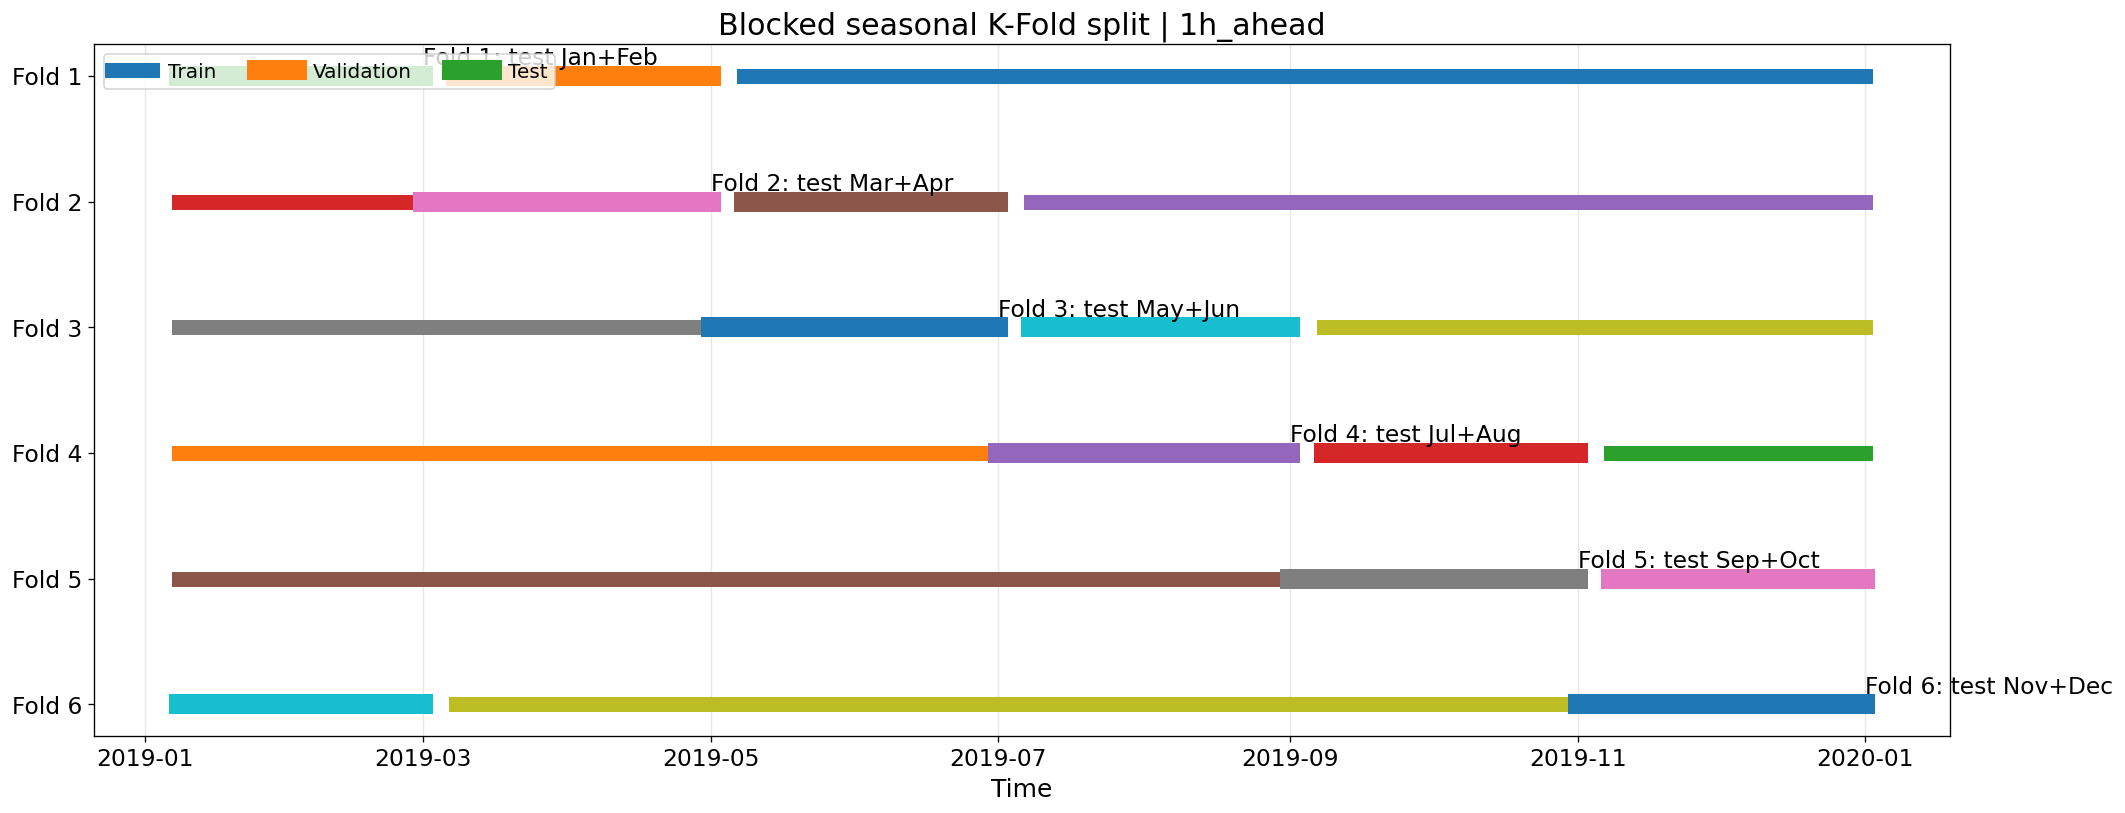

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/figures/blocked_kfold_1h_ahead.png


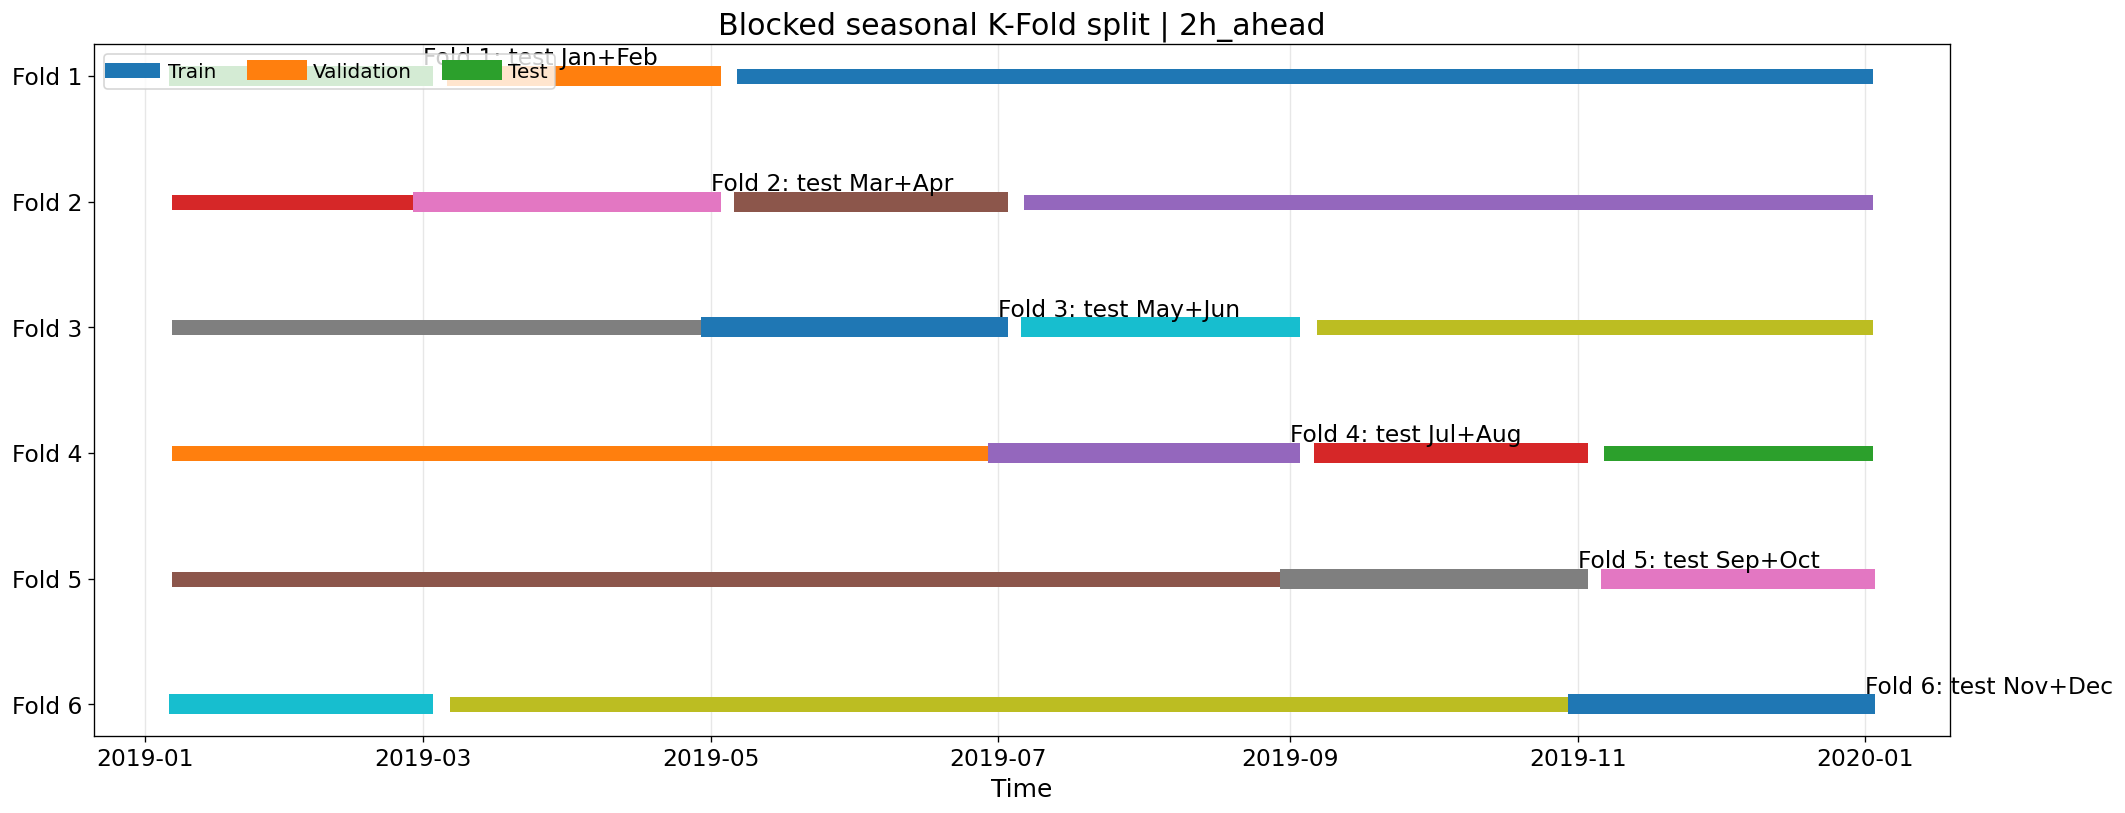

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/figures/blocked_kfold_2h_ahead.png


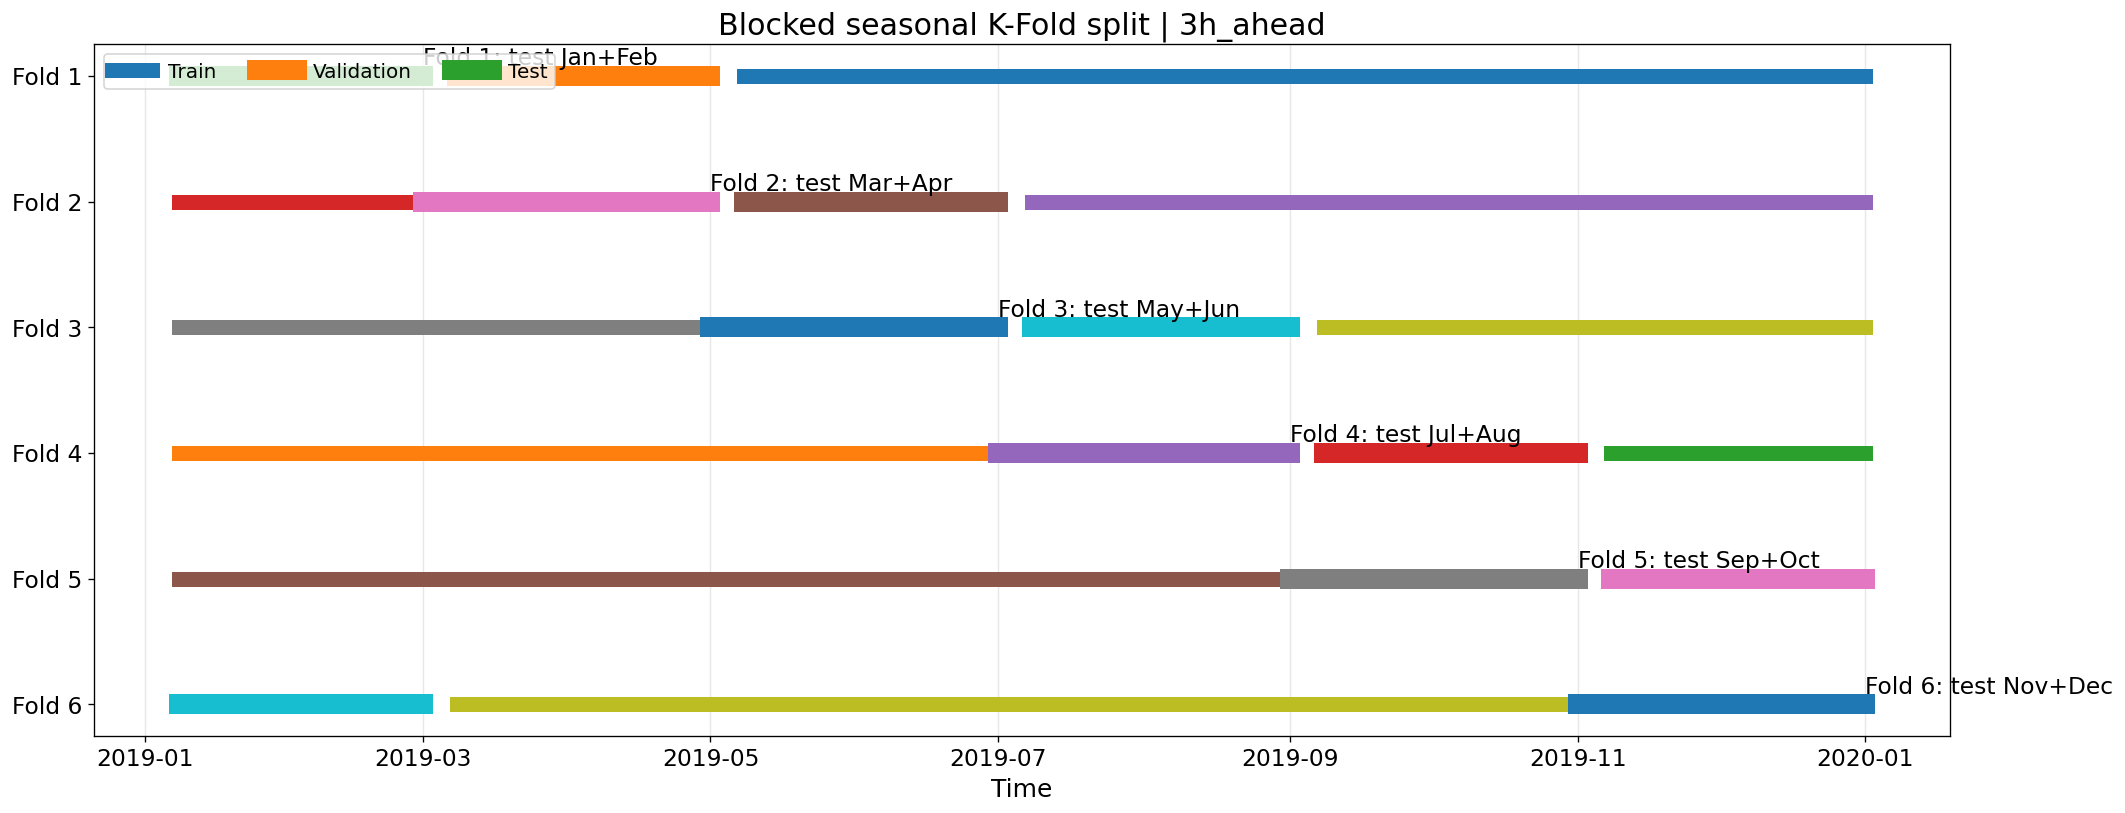

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/figures/blocked_kfold_3h_ahead.png


In [ ]:
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (18, 9),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
})


def _plot_segments(ax, segments, y, label=None, linewidth=10):
    first = True
    for start, end in segments:
        ax.plot([start, end], [y, y], linewidth=linewidth, label=label if first else None)
        first = False


def plot_cv_folds(task="1h_ahead"):
    sub = cv_fold_summary[cv_fold_summary["task"] == task].copy().sort_values("fold_id")
    fig, ax = plt.subplots(figsize=(18, 7))

    y_positions = np.arange(len(sub))[::-1]
    for y, (_, row) in zip(y_positions, sub.iterrows()):
        _plot_segments(ax, row["train_segments"], y, label="Train" if y == y_positions[0] else None, linewidth=9)
        _plot_segments(ax, row["val_segments"], y, label="Validation" if y == y_positions[0] else None, linewidth=12)
        _plot_segments(ax, row["test_segments"], y, label="Test" if y == y_positions[0] else None, linewidth=12)
        ax.text(row["test_end"], y + 0.14, f"Fold {int(row['fold_id'])}: test {row['test_block']}", va="center")

    ax.set_yticks(y_positions)
    ax.set_yticklabels([f"Fold {int(f)}" for f in sub["fold_id"]])
    ax.set_xlabel("Time")
    ax.set_title(f"Blocked seasonal K-Fold split | {task}")
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend(loc="upper left", ncol=3)
    fig.tight_layout()
    out_path = FIG_DIR / f"blocked_kfold_{task}.png"
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

for task in HORIZONS.keys():
    plot_cv_folds(task)


## 11. Visualize RMSE and R2 across model groups

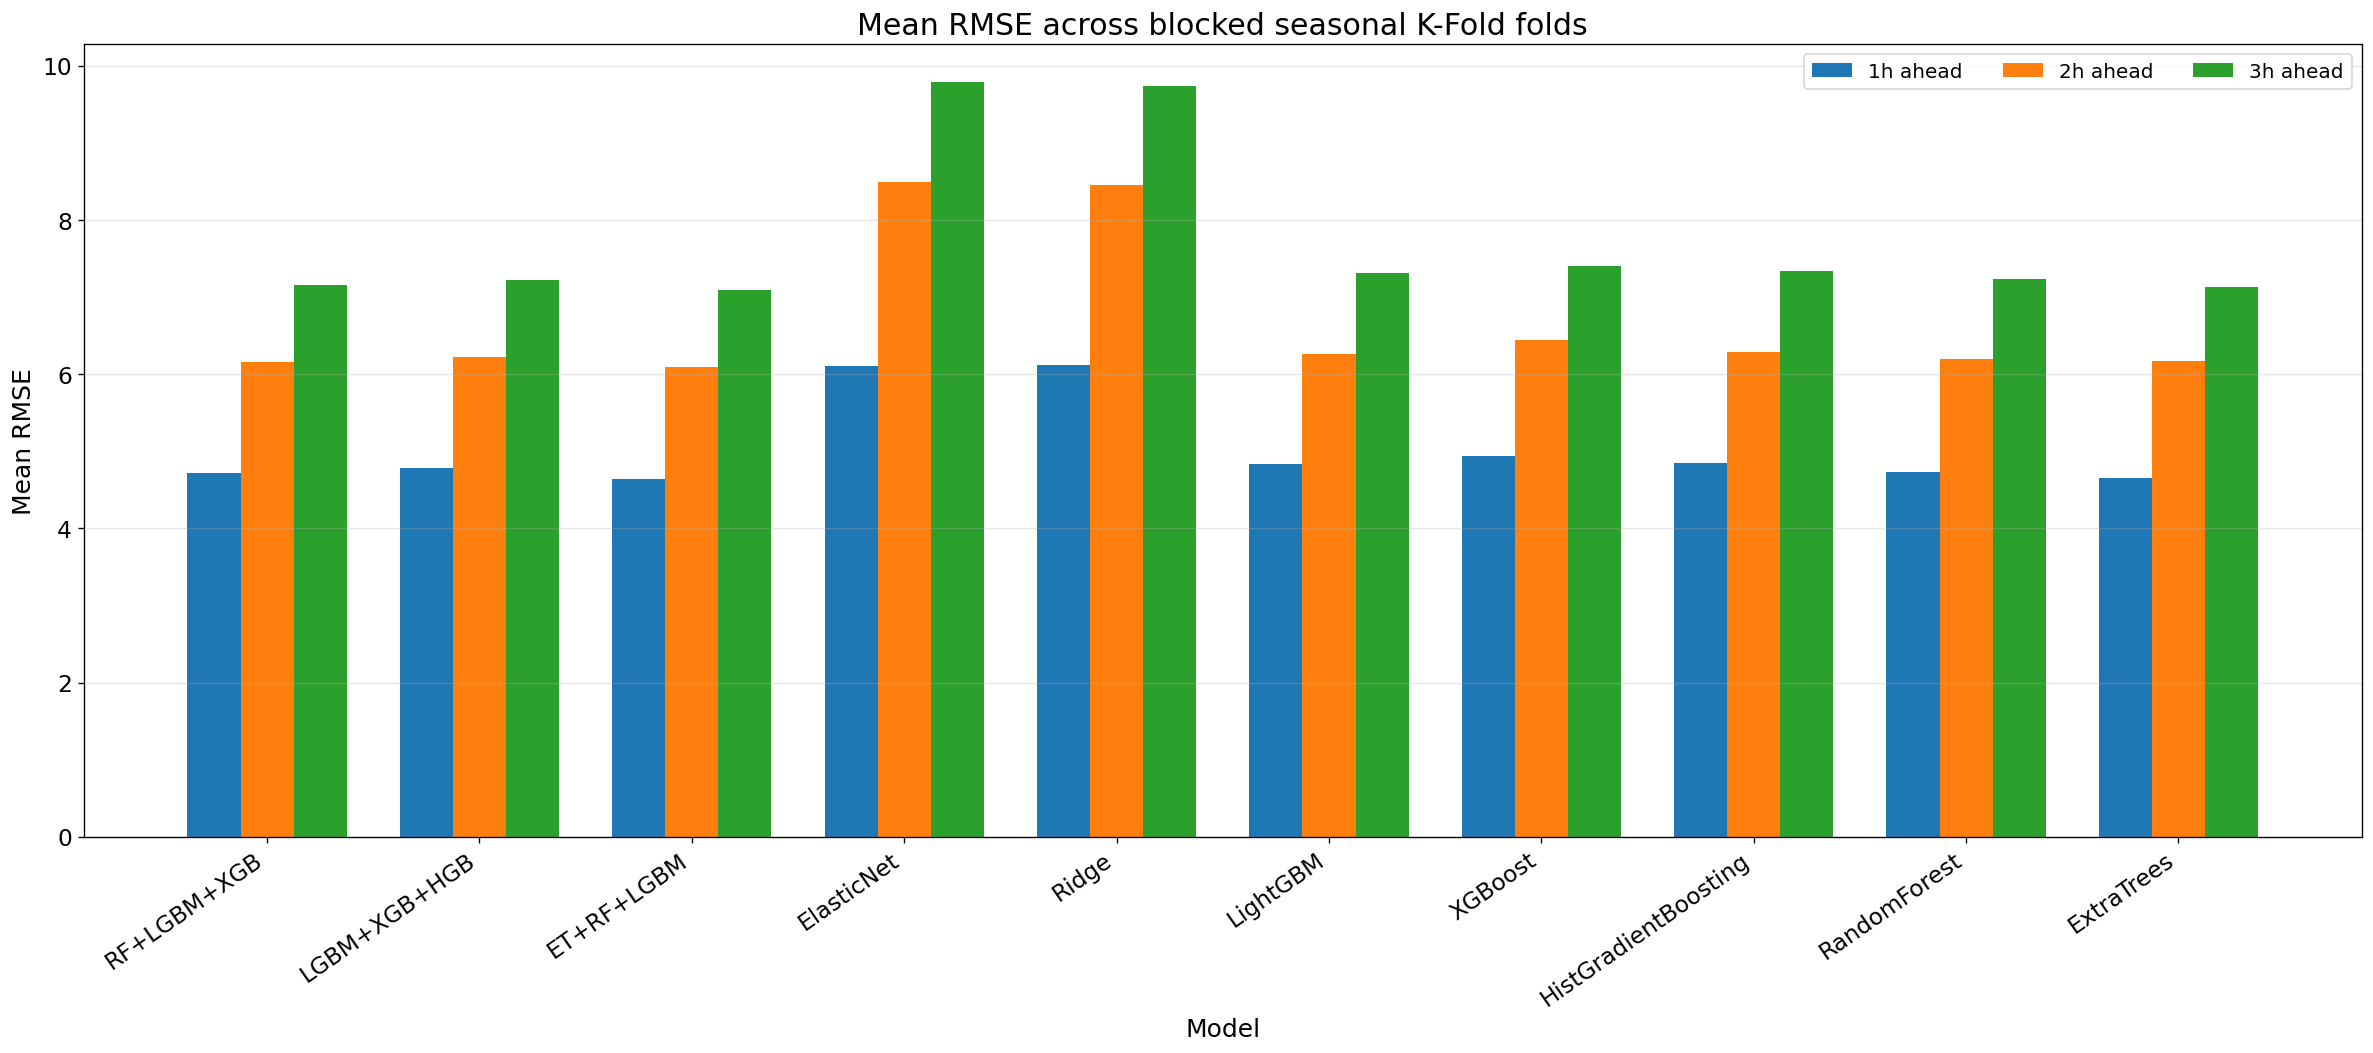

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/figures/blocked_kfold_RMSE_mean.png


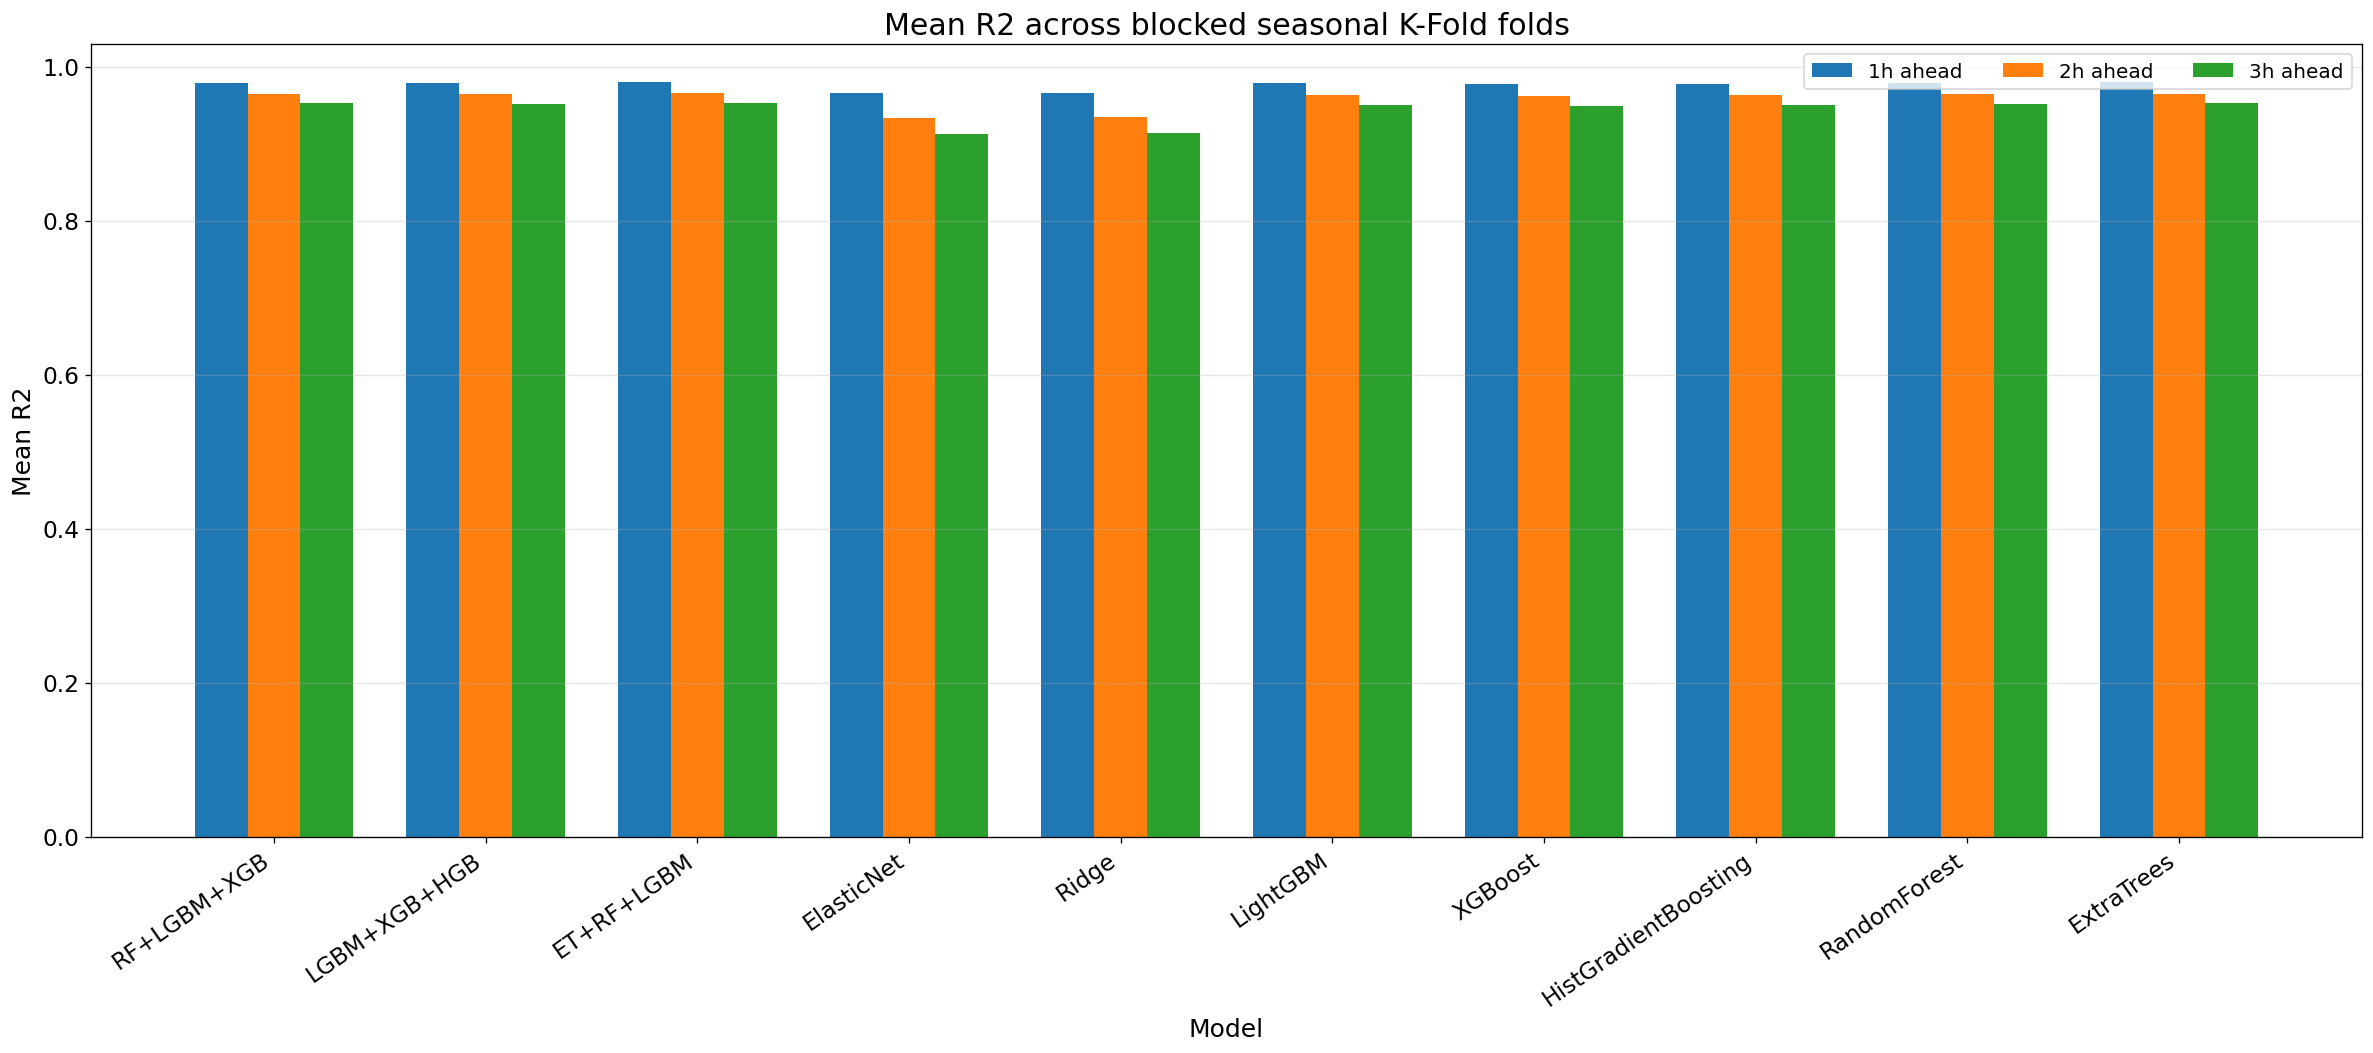

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/figures/blocked_kfold_R2_mean.png


In [ ]:
def plot_metric_summary(metric="RMSE_mean", title_metric="Mean RMSE"):
    selected_methods = [
        "RF+LGBM+XGB", "LGBM+XGB+HGB", "ET+RF+LGBM",
        "ElasticNet", "Ridge", "LightGBM", "XGBoost", "HistGradientBoosting",
        "RandomForest", "ExtraTrees", "ANN", "RNN", "LSTM", "CNN"
    ]
    plot_df = cv_summary[cv_summary["method"].isin(selected_methods)].copy()
    if len(plot_df) == 0:
        print("No selected methods found for plotting.")
        return

    plot_df["method"] = pd.Categorical(plot_df["method"], categories=selected_methods, ordered=True)
    pivot = plot_df.pivot_table(index="method", columns="task", values=metric, aggfunc="first")
    existing_cols = [c for c in ["1h_ahead", "2h_ahead", "3h_ahead"] if c in pivot.columns]
    pivot = pivot[existing_cols]

    fig, ax = plt.subplots(figsize=(20, 9))
    x = np.arange(len(pivot.index))
    width = 0.25

    for i, col in enumerate(pivot.columns):
        ax.bar(x + (i - 1) * width, pivot[col], width=width, label=col.replace("_ahead", " ahead"))

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=35, ha="right")
    ax.set_ylabel(title_metric)
    ax.set_xlabel("Model")
    ax.set_title(f"{title_metric} across blocked seasonal K-Fold folds")
    ax.legend(ncol=3)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    out_path = FIG_DIR / f"blocked_kfold_{metric}.png"
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

plot_metric_summary("RMSE_mean", "Mean RMSE")
plot_metric_summary("R2_mean", "Mean R2")

## 12. Deep learning cross-validation experiments

Phần này giữ nhóm ANN, RNN, LSTM, CNN giống notebook gốc, nhưng chạy theo từng blocked seasonal K-Fold split. Nếu chạy quá lâu trên Colab CPU, có thể giảm `DL_EPOCHS` hoặc đặt `RUN_DEEP_LEARNING = False`.


In [ ]:
RUN_DEEP_LEARNING = True
DL_EPOCHS = 10
DL_WINDOW = 4
DL_BATCH_SIZE = 64

if RUN_DEEP_LEARNING:
    try:
        import tensorflow as tf
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, SimpleRNN, Dropout
        from tensorflow.keras.callbacks import EarlyStopping

        tf.random.set_seed(RANDOM_STATE)

        def create_sequences(X, y, window):
            Xs, ys = [], []
            for i in range(len(X) - window):
                Xs.append(X[i:(i + window)])
                ys.append(y[i + window])
            return np.array(Xs), np.array(ys)

        def build_ann(input_dim):
            model = Sequential([
                Dense(64, activation="relu", input_dim=input_dim),
                Dropout(0.2),
                Dense(32, activation="relu"),
                Dense(1)
            ])
            model.compile(optimizer="adam", loss="mse")
            return model

        def build_rnn(window, features):
            model = Sequential([
                SimpleRNN(32, activation="relu", input_shape=(window, features)),
                Dense(1)
            ])
            model.compile(optimizer="adam", loss="mse")
            return model

        def build_lstm(window, features):
            model = Sequential([
                LSTM(50, activation="relu", input_shape=(window, features)),
                Dense(1)
            ])
            model.compile(optimizer="adam", loss="mse")
            return model

        def build_cnn(window, features):
            model = Sequential([
                Conv1D(filters=64, kernel_size=2, activation="relu", input_shape=(window, features)),
                Flatten(),
                Dense(32, activation="relu"),
                Dense(1)
            ])
            model.compile(optimizer="adam", loss="mse")
            return model

        def evaluate_dl_one_fold(task, H, fold, feature_cols):
            train = fold["train"].copy()
            val = fold["val"].copy()
            test = fold["test"].copy()
            capacity = float(pd.concat([train, val])["y"].max())

            scaler = StandardScaler()
            X_train = scaler.fit_transform(train[feature_cols])
            X_val = scaler.transform(val[feature_cols])
            X_test = scaler.transform(test[feature_cols])

            y_train = train["y"].to_numpy()
            y_val = val["y"].to_numpy()
            y_test = test["y"].to_numpy()

            X_seq_train, y_seq_train = create_sequences(X_train, y_train, DL_WINDOW)
            X_seq_val, y_seq_val = create_sequences(X_val, y_val, DL_WINDOW)
            X_seq_test, y_seq_test = create_sequences(X_test, y_test, DL_WINDOW)

            X_ann_train, y_ann_train = X_train[DL_WINDOW:], y_train[DL_WINDOW:]
            X_ann_val, y_ann_val = X_val[DL_WINDOW:], y_val[DL_WINDOW:]
            X_ann_test, y_ann_test = X_test[DL_WINDOW:], y_test[DL_WINDOW:]

            test_meta_ann = test.iloc[DL_WINDOW:].copy()
            test_meta_seq = test.iloc[DL_WINDOW:].copy()

            callback = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
            rows = []

            dl_models = [
                ("ANN", build_ann(len(feature_cols)), X_ann_train, y_ann_train, X_ann_val, y_ann_val, X_ann_test, test_meta_ann),
                ("RNN", build_rnn(DL_WINDOW, len(feature_cols)), X_seq_train, y_seq_train, X_seq_val, y_seq_val, X_seq_test, test_meta_seq),
                ("LSTM", build_lstm(DL_WINDOW, len(feature_cols)), X_seq_train, y_seq_train, X_seq_val, y_seq_val, X_seq_test, test_meta_seq),
                ("CNN", build_cnn(DL_WINDOW, len(feature_cols)), X_seq_train, y_seq_train, X_seq_val, y_seq_val, X_seq_test, test_meta_seq),
            ]

            for name, model, Xtr, ytr, Xva, yva, Xte, meta in dl_models:
                print(f"  DL fold {fold['fold_id']} | {task} | training {name}")
                model.fit(
                    Xtr, ytr,
                    validation_data=(Xva, yva),
                    epochs=DL_EPOCHS,
                    batch_size=DL_BATCH_SIZE,
                    verbose=0,
                    callbacks=[callback],
                )
                pred = model.predict(Xte, verbose=0).flatten()
                m = calc_metrics(meta, pred, capacity)
                rows.append({
                    "run_mode": RUN_MODES[0],
                    "task": task,
                    "fold_id": fold["fold_id"],
                    "method_type": "deep_learning",
                    "method": name,
                    **m,
                    "train_start": fold["train_start"],
                    "train_end": fold["train_end"],
                    "val_start": fold["val_start"],
                    "val_end": fold["val_end"],
                    "test_start": fold["test_start"],
                    "test_end": fold["test_end"],
                })
            return pd.DataFrame(rows)

        all_dl_cv_results = []
        for task, H in HORIZONS.items():
            data, feature_cols, registry_df = build_intraday_dataset(H, run_mode=RUN_MODES[0])
            data["horizon_steps"] = H
            max_source_lag_steps = int(registry_df["source_lag_steps"].fillna(0).max())
            purge_steps = max_source_lag_steps if CV_PURGE_AFTER_HELDOUT else 0
            folds = make_blocked_seasonal_kfold_folds(
                data, H,
                months_per_block=CV_MONTHS_PER_BLOCK,
                n_folds=CV_N_FOLDS,
                validation_offset=CV_VALIDATION_OFFSET,
                purge_after_heldout_steps=purge_steps,
            )
            for fold in folds:
                dl_df = evaluate_dl_one_fold(task, H, fold, feature_cols)
                all_dl_cv_results.append(dl_df)

        dl_cv_results = pd.concat(all_dl_cv_results, ignore_index=True)
        dl_cv_results.to_csv(OUTPUT_DIR / "all_dl_cv_test_results.csv", index=False)

        cv_test_results_with_dl = pd.concat([cv_test_results, dl_cv_results], ignore_index=True)
        cv_test_results_with_dl.to_csv(OUTPUT_DIR / "all_cv_test_results_with_dl.csv", index=False)

        dl_summary = (
            dl_cv_results
            .groupby(["task", "method"])[["RMSE", "R2", "daylight_safe_MAPE_percent"]]
            .agg(["mean", "std"])
            .reset_index()
        )
        display(dl_summary)

    except Exception as e:
        print("Deep learning section skipped because of error:", repr(e))
        cv_test_results_with_dl = cv_test_results.copy()
else:
    cv_test_results_with_dl = cv_test_results.copy()
    print("Deep learning CV skipped. Set RUN_DEEP_LEARNING = True to run ANN/RNN/LSTM/CNN.")

  DL fold 1 | 1h_ahead | training ANN
  DL fold 1 | 1h_ahead | training RNN
  DL fold 1 | 1h_ahead | training LSTM
  DL fold 1 | 1h_ahead | training CNN
  DL fold 2 | 1h_ahead | training ANN
  DL fold 2 | 1h_ahead | training RNN
  DL fold 2 | 1h_ahead | training LSTM
  DL fold 2 | 1h_ahead | training CNN
  DL fold 3 | 1h_ahead | training ANN
  DL fold 3 | 1h_ahead | training RNN
  DL fold 3 | 1h_ahead | training LSTM
  DL fold 3 | 1h_ahead | training CNN
  DL fold 4 | 1h_ahead | training ANN
  DL fold 4 | 1h_ahead | training RNN
  DL fold 4 | 1h_ahead | training LSTM
  DL fold 4 | 1h_ahead | training CNN
  DL fold 5 | 1h_ahead | training ANN
  DL fold 5 | 1h_ahead | training RNN
  DL fold 5 | 1h_ahead | training LSTM
  DL fold 5 | 1h_ahead | training CNN
  DL fold 6 | 1h_ahead | training ANN
  DL fold 6 | 1h_ahead | training RNN
  DL fold 6 | 1h_ahead | training LSTM
  DL fold 6 | 1h_ahead | training CNN
  DL fold 1 | 2h_ahead | training ANN
  DL fold 1 | 2h_ahead | training RNN
  DL f

task method      RMSE                  R2           daylight_safe_MAPE_percent          
                         mean       std      mean       std                       mean       std
0   1h_ahead    ANN  5.038832  1.521766  0.975478  0.009726                  17.866780  3.388287
1   1h_ahead    CNN  6.008704  1.613326  0.965111  0.012577                  21.281664  3.745462
2   1h_ahead   LSTM  6.388403  1.562526  0.959213  0.018415                  22.046058  4.203845
3   1h_ahead    RNN  6.455676  1.783767  0.959592  0.013879                  25.002733  5.082506
4   2h_ahead    ANN  6.403884  1.999037  0.961477  0.010985                  21.910772  3.877255
5   2h_ahead    CNN  7.072906  2.043710  0.952884  0.010097                  25.185254  3.091759
6   2h_ahead   LSTM  7.347322  2.442954  0.950098  0.014214                  25.240371  4.887910
7   2h_ahead    RNN  7.804579  1.985635  0.941372  0.013849                  31.027256  5.143052
8   3h_ahead    ANN  7.698866  2.179607  0.943188  0.017934                  26.151101  4.154549
9   3h_ahead    CNN  8.121463  2.281999  0.938230  0.012084                  28.795934  4.770394
10  3h_ahead   LSTM  8.536022  2.594340  0.932631  0.014735                  27.979809  4.608376
11  3h_ahead    RNN  8.463869  2.414507  0.933716  0.008746                  31.740464  4.445691

## 13. Feature importance for all 67 input features

Cell này tính feature importance cho toàn bộ 67 features. Với tree/boosting models dùng `feature_importances_`; với linear models dùng trị tuyệt đối hệ số; nếu model không có importance trực tiếp thì dùng permutation importance trên validation subset. Với ensemble, importance là trung bình importance của các member models.

Feature importance cũng được tính theo blocked seasonal K-Fold để thống nhất với cách đánh giá mới.


Selected tabular method for feature importance:


,task,method_type,method,RMSE_mean,R2_mean
9,1h_ahead,ensemble,Top3Mean(ExtraTrees+XGBoost+RandomForest),2.595867,0.984498
30,2h_ahead,ensemble,Top3Mean(ExtraTrees+XGBoost+RandomForest),3.660352,0.969178
50,3h_ahead,ensemble,Top3Mean(XGBoost+ExtraTrees+GradientBoosting),4.229126,0.958855


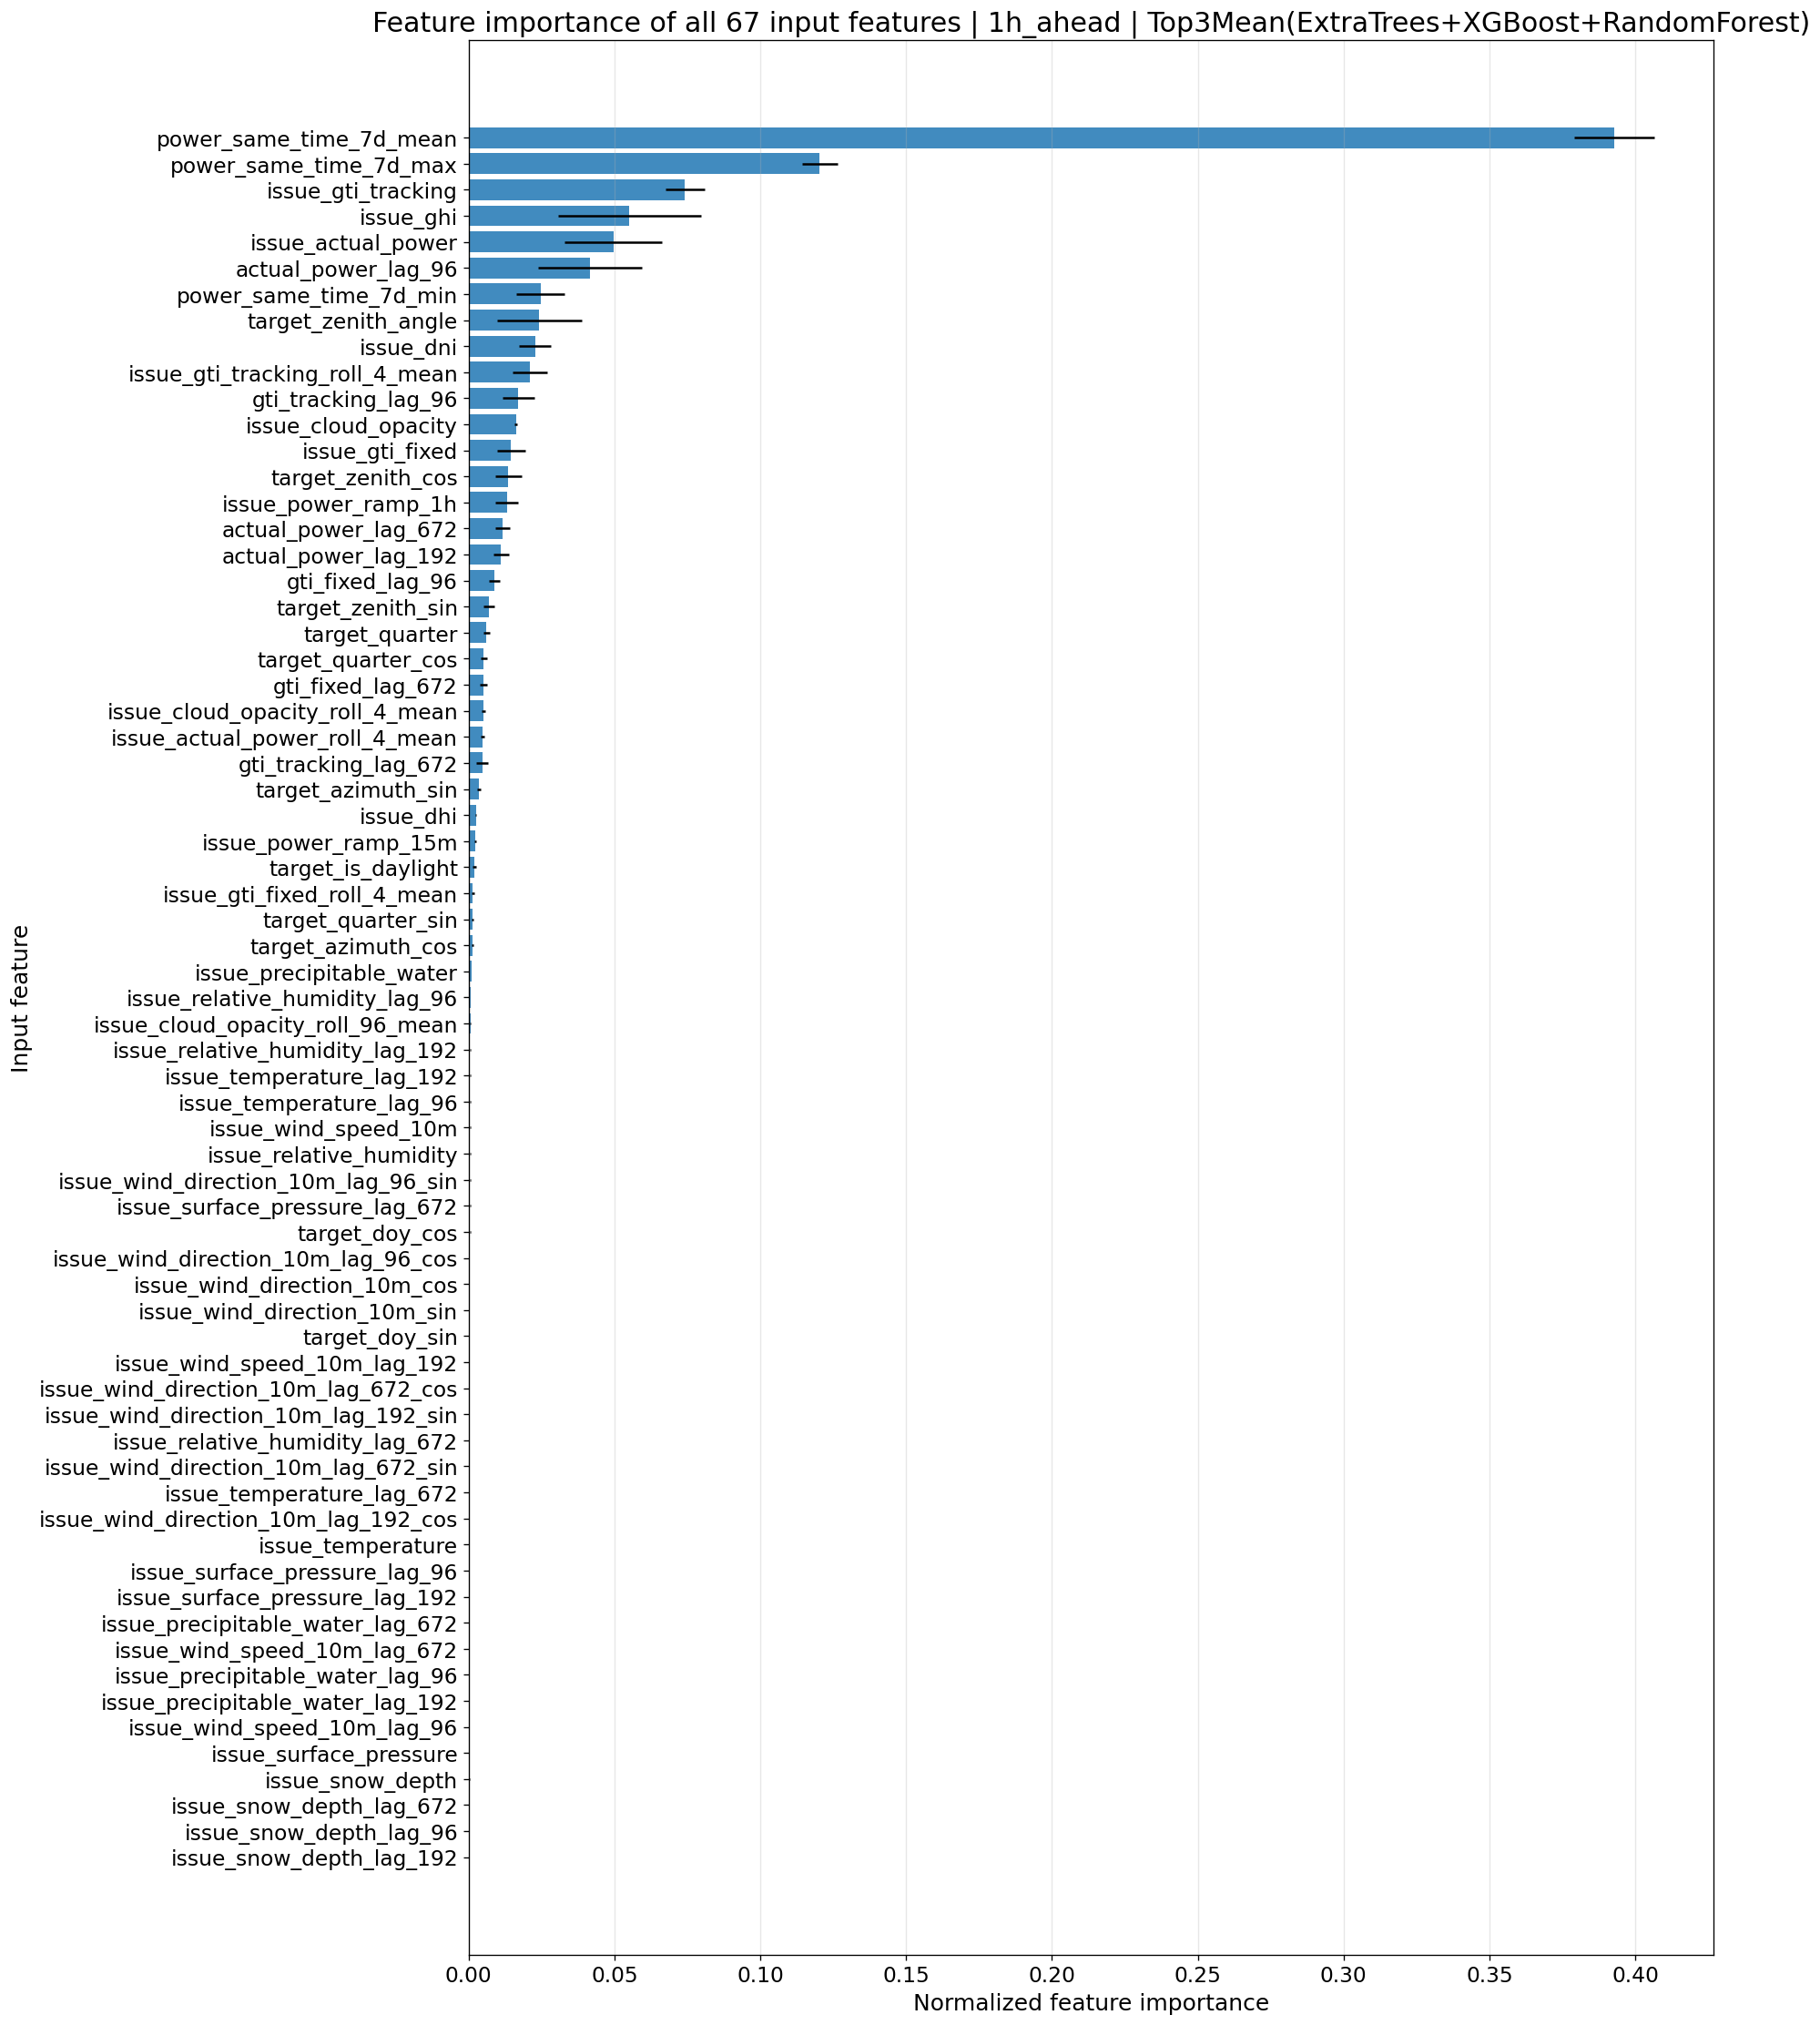

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/feature_importance/feature_importance_all_67_1h_ahead.csv
Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/feature_importance/feature_importance_all_67_1h_ahead.png


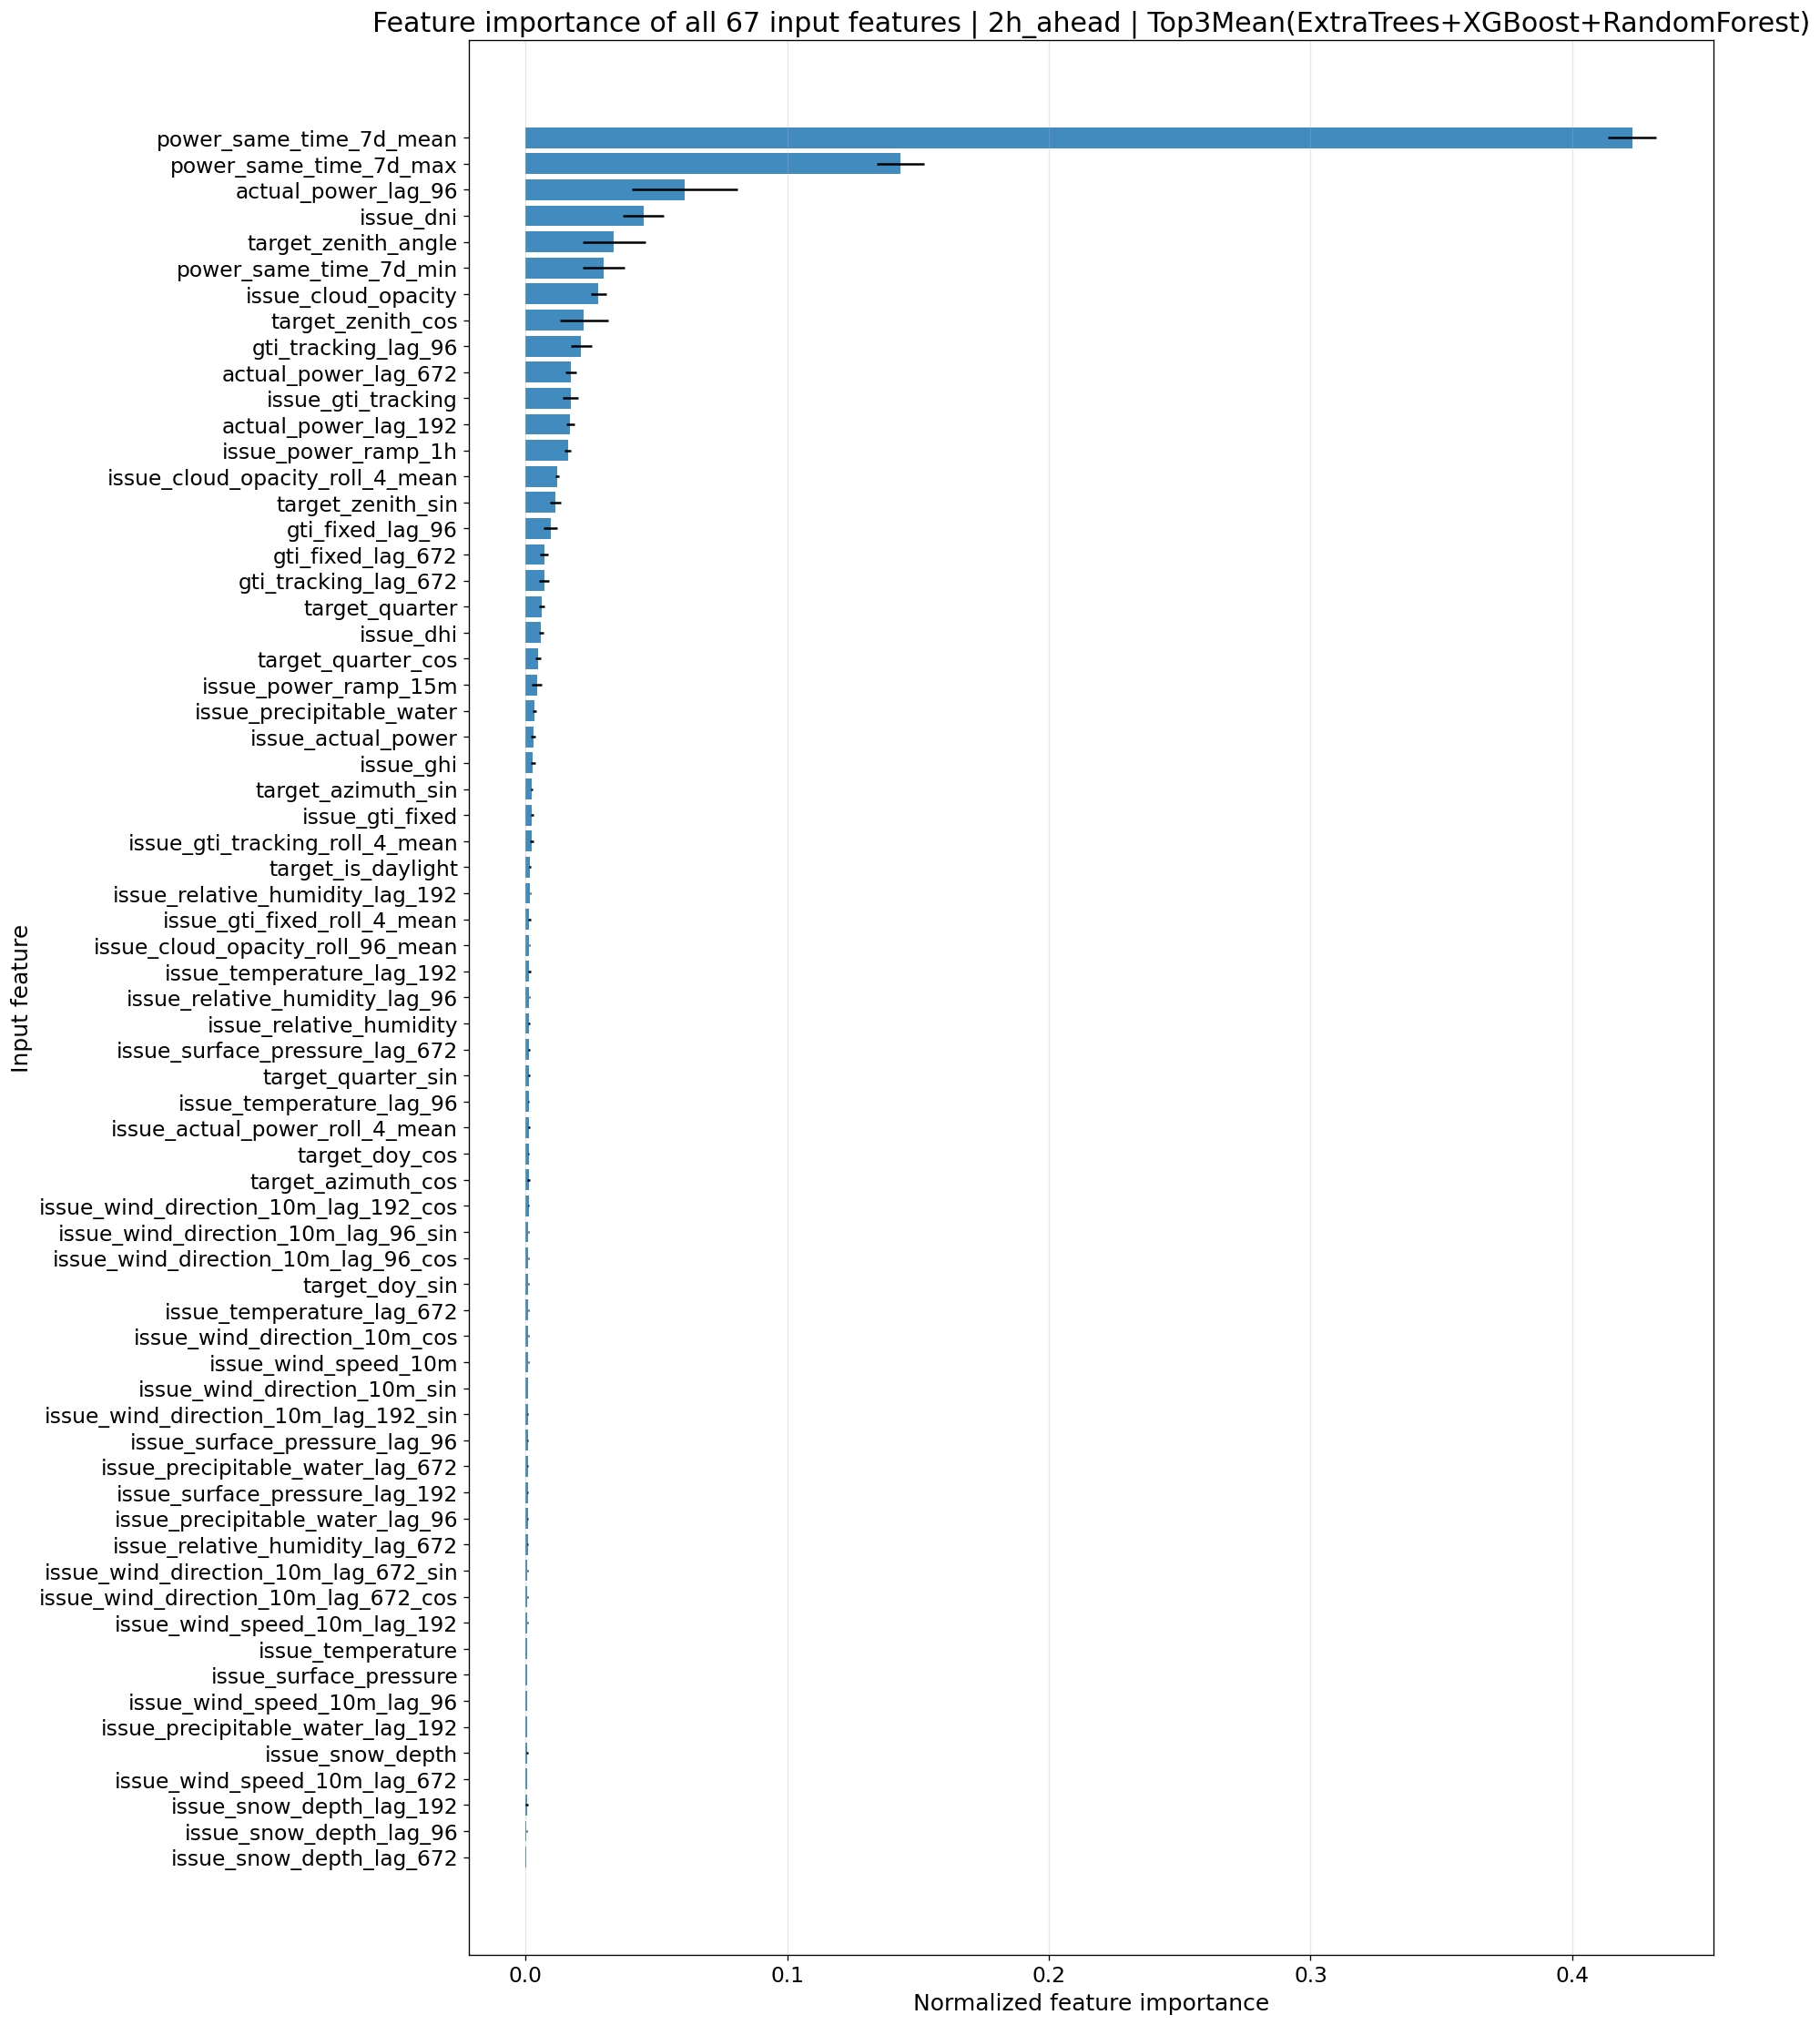

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/feature_importance/feature_importance_all_67_2h_ahead.csv
Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/feature_importance/feature_importance_all_67_2h_ahead.png


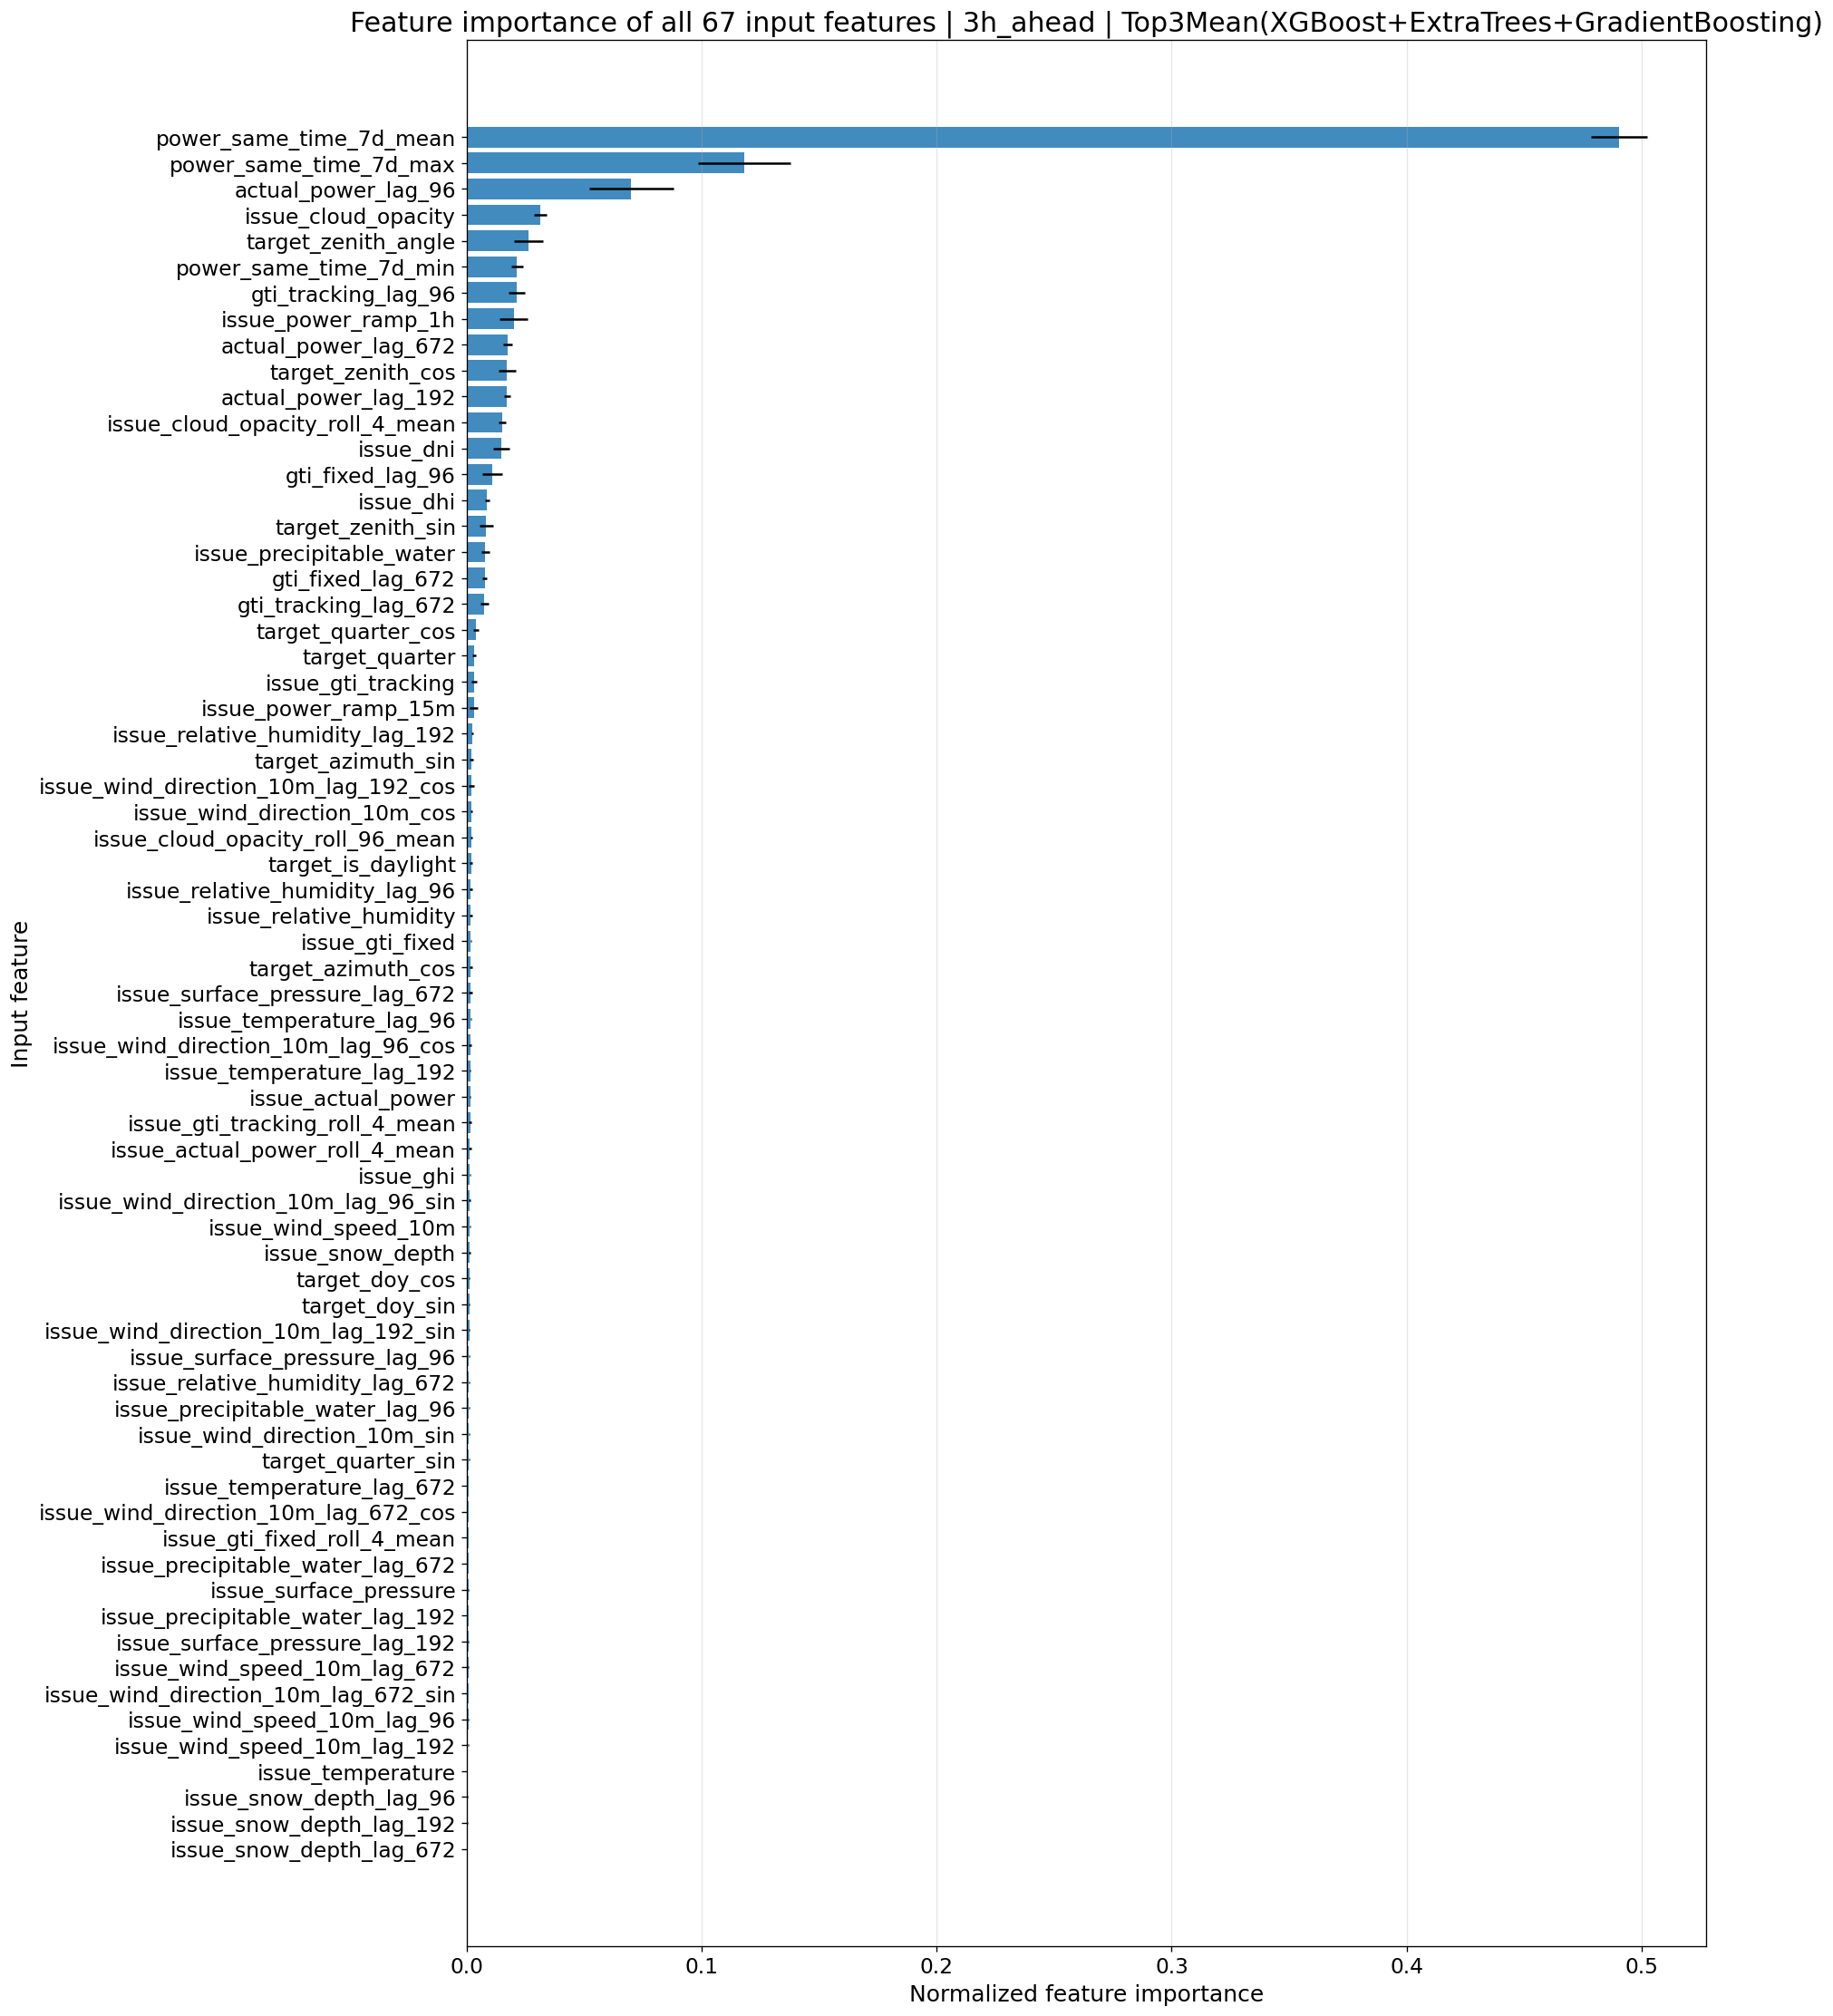

Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/feature_importance/feature_importance_all_67_3h_ahead.csv
Saved: /content/pv_multi_model_blocked_seasonal_kfold_results/feature_importance/feature_importance_all_67_3h_ahead.png
Combined feature importance saved to: /content/pv_multi_model_blocked_seasonal_kfold_results/feature_importance/feature_importance_all_67_all_horizons.csv


,task,selected_method,feature,importance_mean,importance_std
0,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),power_same_time_7d_mean,0.392755,0.013615
1,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),power_same_time_7d_max,0.120371,0.006156
2,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),issue_gti_tracking,0.074107,0.006706
3,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),issue_ghi,0.055102,0.024479
4,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),issue_actual_power,0.049602,0.016673
5,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),actual_power_lag_96,0.041664,0.017797
6,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),power_same_time_7d_min,0.024708,0.008238
7,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),target_zenith_angle,0.024271,0.014623
8,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),issue_dni,0.022727,0.005369
9,1h_ahead,Top3Mean(ExtraTrees+XGBoost+RandomForest),issue_gti_tracking_roll_4_mean,0.021042,0.005948


In [ ]:
from sklearn.inspection import permutation_importance

FEATURE_IMPORTANCE_DIR = OUTPUT_DIR / "feature_importance"
FEATURE_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)


def get_inner_estimator(fitted_model):
    if isinstance(fitted_model, Pipeline):
        return fitted_model.steps[-1][1]
    return fitted_model


def normalize_importance(values):
    values = np.asarray(values, dtype=float)
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    values = np.abs(values)
    total = values.sum()
    if total <= 0:
        return values
    return values / total


def extract_model_importance(fitted_model, X_ref, y_ref, feature_cols):
    inner = get_inner_estimator(fitted_model)

    if hasattr(inner, "feature_importances_"):
        return normalize_importance(inner.feature_importances_)

    if hasattr(inner, "coef_"):
        coef = np.ravel(inner.coef_)
        return normalize_importance(coef)

    # Fallback for models such as HistGradientBoostingRegressor.
    # Use a limited validation sample to keep runtime controlled.
    sample_n = min(len(X_ref), 1500)
    X_sample = X_ref.iloc[:sample_n]
    y_sample = y_ref.iloc[:sample_n]

    perm = permutation_importance(
        fitted_model,
        X_sample,
        y_sample,
        scoring="neg_root_mean_squared_error",
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    return normalize_importance(perm.importances_mean)


def resolve_method_to_members(method_name):
    if method_name in ENSEMBLE_MEMBER_MAP:
        return ENSEMBLE_MEMBER_MAP[method_name]
    if method_name.startswith("Top3Mean(") and method_name.endswith(")"):
        inside = method_name[len("Top3Mean("):-1]
        return inside.split("+")
    return [method_name]


def compute_cv_feature_importance_for_task(task, H, selected_method):
    data, feature_cols, registry_df = build_intraday_dataset(H, run_mode=RUN_MODES[0])
    data["horizon_steps"] = H

    if len(feature_cols) != 67:
        raise ValueError(f"Expected 67 feature columns, got {len(feature_cols)}")

    folds = make_blocked_seasonal_kfold_folds(
        data,
        H,
        months_per_block=CV_MONTHS_PER_BLOCK,
        n_folds=CV_N_FOLDS,
        validation_offset=CV_VALIDATION_OFFSET,
        purge_after_heldout_steps=int(registry_df["source_lag_steps"].fillna(0).max()) if CV_PURGE_AFTER_HELDOUT else 0,
    )

    models = make_model_candidates()
    members = resolve_method_to_members(selected_method)
    fold_importances = []

    for fold in folds:
        train = fold["train"].copy()
        val = fold["val"].copy()
        dev = fold["dev"].copy()
        capacity = float(dev["y"].max())
        dev_w = make_training_weights(dev, capacity)

        member_imps = []
        for member in members:
            if member not in models:
                print(f"Skipping unavailable member {member} for {task}")
                continue
            fitted = fit_model_safely(models[member], dev[feature_cols], dev["y"], dev_w)
            imp = extract_model_importance(fitted, val[feature_cols], val["y"], feature_cols)
            member_imps.append(imp)

        if len(member_imps) == 0:
            continue

        fold_imp = normalize_importance(np.mean(member_imps, axis=0))
        fold_importances.append(fold_imp)

    if len(fold_importances) == 0:
        raise ValueError(f"No importances computed for {task} | {selected_method}")

    imp_mean = np.mean(fold_importances, axis=0)
    imp_std = np.std(fold_importances, axis=0)

    out = pd.DataFrame({
        "task": task,
        "selected_method": selected_method,
        "feature": feature_cols,
        "importance_mean": imp_mean,
        "importance_std": imp_std,
    }).sort_values("importance_mean", ascending=False)

    return out


# Choose the best tabular model/ensemble by mean CV RMSE for each horizon.
# Deep learning is not used for feature importance here because the 67 engineered tabular features
# are most interpretable with ML/ensemble models.
tabular_summary = cv_summary[cv_summary["method_type"].isin(["machine_learning", "ensemble"])].copy()
best_tabular_by_rmse = (
    tabular_summary
    .sort_values(["task", "RMSE_mean"], ascending=[True, True])
    .groupby("task")
    .head(1)
)

print("Selected tabular method for feature importance:")
display(best_tabular_by_rmse[["task", "method_type", "method", "RMSE_mean", "R2_mean"]])

all_importances = []

for _, row in best_tabular_by_rmse.iterrows():
    task = row["task"]
    H = HORIZONS[task]
    method = row["method"]

    imp_df = compute_cv_feature_importance_for_task(task, H, method)
    all_importances.append(imp_df)

    csv_path = FEATURE_IMPORTANCE_DIR / f"feature_importance_all_67_{task}.csv"
    imp_df.to_csv(csv_path, index=False)

    # Plot all 67 features.
    plot_df = imp_df.sort_values("importance_mean", ascending=True)
    fig_height = max(16, 0.28 * len(plot_df))
    fig, ax = plt.subplots(figsize=(16, fig_height))

    ax.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"], alpha=0.85)
    ax.set_xlabel("Normalized feature importance")
    ax.set_ylabel("Input feature")
    ax.set_title(f"Feature importance of all 67 input features | {task} | {method}")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()

    fig_path = FEATURE_IMPORTANCE_DIR / f"feature_importance_all_67_{task}.png"
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()

    print("Saved:", csv_path)
    print("Saved:", fig_path)

feature_importance_all = pd.concat(all_importances, ignore_index=True)
feature_importance_all.to_csv(FEATURE_IMPORTANCE_DIR / "feature_importance_all_67_all_horizons.csv", index=False)

print("Combined feature importance saved to:", FEATURE_IMPORTANCE_DIR / "feature_importance_all_67_all_horizons.csv")
display(feature_importance_all.head(30))

## 14. Notes for interpretation

- Đây là **blocked seasonal K-Fold**, không phải random K-Fold và cũng không phải expanding-window chronological CV.
- Dữ liệu được chia thành các block lịch liên tiếp, mặc định mỗi block 2 tháng.
- Mỗi fold train lại từ đầu; fold sau không biết kết quả, prediction, weight hay model của fold trước.
- Một block từng làm test ở fold này có thể được dùng làm train ở fold khác, đúng tinh thần K-Fold.
- Thiết kế này phù hợp để đánh giá robustness theo mùa và so sánh mô hình khi dataset chỉ có một năm.
- Không gọi đây là strict future-deployment forecasting split, vì train set của một fold có thể chứa các tháng sau test block.
- Không có target-time measured variables trong input features.
- Feature importance được tính trên toàn bộ 67 input features và lưu cả dạng CSV + PNG.
